# Introduction

Cloud detection is important in satellite image analysis because clouds can strongly affect the radiance measured by the sensor. In polar regions, this problem is harder because clouds and snow or ice surfaces often look similar. They can both appear bright, so simple methods do not work very well. MISR is useful here because it observes the same scene from several viewing angles, and this gives more information for telling clouds from the surface.

In this lab, we study pixel-level cloud classification using MISR image data. The dataset has 164 images, but only 3 of them have expert labels. In the labeled images, each pixel is marked as cloud, no-cloud, or unlabeled. Each pixel also includes x and y coordinates, three given features called NDAI, SD, and CORR, and radiance values from five viewing angles named DF, CF, BF, AF, and AN.

This dataset is challenging for two reasons. First, the amount of labeled data is very small. Second, the final model should work on new images that do not have expert labels. Because of this, we first do some exploratory data analysis to understand the labeled images and the feature patterns. Then we build some new features, including spatial features and autoencoder embeddings. After that, we compare several classifiers and check how well they work on held-out images.


# EDA

We have 164 images in total, and only three of them have expert labels. In these labeled images, each pixel is marked as cloud, no cloud, or unlabeled. Each pixel also has x and y coordinates, three given features called NDAI, SD, and CORR, and five radiance values from different viewing angles.

## Expert label maps (X, Y coordinates)

For the three labeled images, we plot the expert labels on the x and y map to see how cloud and no-cloud pixels are distributed in space.

In [2]:
import glob
import numpy as np
import matplotlib.pyplot as plt

# Load the 3 labeled images and keep the label column
labeled_names = ["O012791.npz", "O013257.npz", "O013490.npz"]
fps = sorted(glob.glob("../data/image_data/*.npz"))
labeled = []
for fp in fps:
    if fp.split("/")[-1] not in labeled_names:
        continue
    npz = np.load(fp)
    key = list(npz.files)[0]
    data = npz[key]  # shape (n_pixels, 11): 0=y, 1=x, 2-9=features, 10=label
    if data.shape[1] != 11:
        continue
    labeled.append(data)

print(f"Loaded {len(labeled)} labeled images.")
for i, d in enumerate(labeled):
    labels_i = d[:, 10]          
    n_cloud = (labels_i == 1).sum()
    n_nocloud = (labels_i == -1).sum()
    n_unlabeled = (labels_i == 0).sum()
    print(
        f"  Image {i+1}: {d.shape[0]} pixels, "
        f"cloud={n_cloud}, no_cloud={n_nocloud}, unlabeled={n_unlabeled}"
    )

Loaded 3 labeled images.
  Image 1: 114973 pixels, cloud=21244, no_cloud=33528, unlabeled=60201
  Image 2: 115000 pixels, cloud=20468, no_cloud=50358, unlabeled=44174
  Image 3: 115032 pixels, cloud=39253, no_cloud=42830, unlabeled=32949


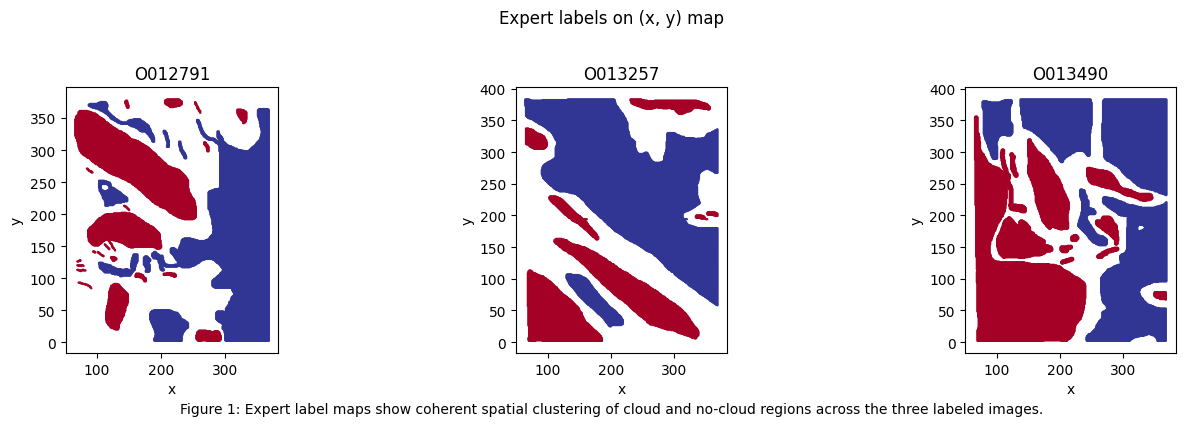

In [3]:
# plot expert labels on (x,y)
import warnings
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message=".*tight_layout.*"
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
titles = ["O012791", "O013257", "O013490"]
for i, (d, ax) in enumerate(zip(labeled, axes)):
    x, y = d[:, 1], d[:, 0]
    lab = d[:, 10]
    m = lab != 0
    s = ax.scatter(x[m], y[m], c=lab[m], cmap="RdYlBu_r", s=0.3, vmin=-1, vmax=1)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(titles[i])
    ax.set_aspect("equal")
plt.suptitle("Expert labels on (x, y) map", y=1.02)
plt.tight_layout()
plt.savefig("../figures/expert_labels_map.png", dpi=150, bbox_inches="tight")
plt.gcf().subplots_adjust(bottom=0.16)
plt.gcf().text(0.5, 0.01, "Figure 1: Expert label maps show coherent spatial clustering of cloud and no-cloud regions across the three labeled images.", ha="center", fontsize=10, wrap=True)
plt.show()

From these three plots, we can see that the labels are not random. Cloud pixels and no-cloud pixels usually appear in large connected regions, so there is a clear spatial pattern. The three images also look different from each other, because some have much more cloud while others have more no-cloud area. In the plot, we do not show the unlabeled pixels. Some of these unlabeled areas seem to be close to the boundary between the two classes, which may mean that these boundary pixels are harder to classify.

## Radiance relationships and class differences

Next, we look at how the five radiance angles are related to each other, and whether cloud and no-cloud pixels look different in radiance and in the three given features NDAI, SD, and CORR.

In [3]:
# Stack all labeled pixels from the three images. Columns: 0=y, 1=x, 2=NDAI, 3=SD, 4=CORR, 5-9=radiance DF,CF,BF,AF,AN, 10=label
data_all = np.vstack([d for d in labeled])
ndai = data_all[:, 2]
sd = data_all[:, 3]
corr = data_all[:, 4]
rad_cols = [5, 6, 7, 8, 9]
rad_names = ["DF", "CF", "BF", "AF", "AN"]
radiances = data_all[:, rad_cols]
labels = data_all[:, 10]
mask = labels != 0
L = labels[mask]
cloud_bool = L == 1
nocloud_bool = L == -1

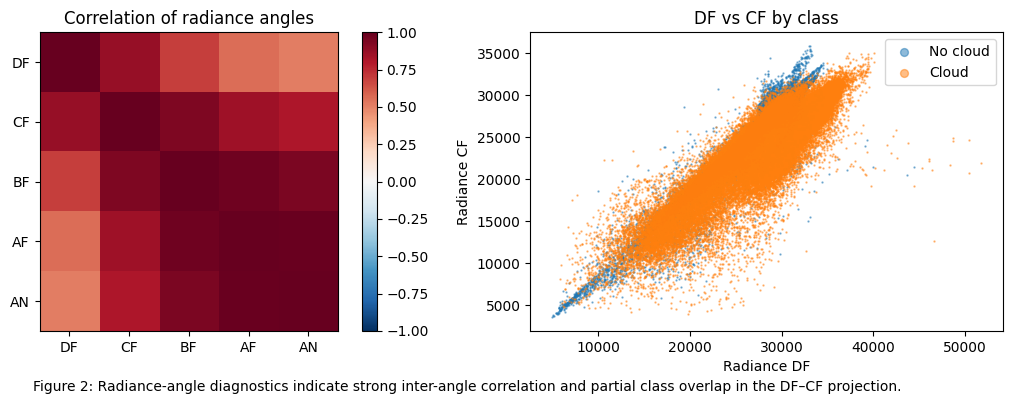

Radiance correlation matrix (rows/cols: DF, CF, BF, AF, AN):
[[1.    0.871 0.688 0.558 0.514]
 [0.871 1.    0.93  0.847 0.809]
 [0.688 0.93  1.    0.972 0.945]
 [0.558 0.847 0.972 1.    0.989]
 [0.514 0.809 0.945 0.989 1.   ]]


In [ ]:
# Correlation heatmap and one example scatterplot
rad_df = radiances[mask]
corr_rad = np.corrcoef(rad_df.T)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
im = axes[0].imshow(corr_rad, vmin=-1, vmax=1, cmap="RdBu_r")
axes[0].set_xticks(range(5))
axes[0].set_xticklabels(rad_names)
axes[0].set_yticks(range(5))
axes[0].set_yticklabels(rad_names)
axes[0].set_title("Correlation of radiance angles")
plt.colorbar(im, ax=axes[0])
# DF vs CF
axes[1].scatter(rad_df[~cloud_bool, 0], rad_df[~cloud_bool, 1], s=0.5, alpha=0.5, label="No cloud", c="C0")
axes[1].scatter(rad_df[cloud_bool, 0], rad_df[cloud_bool, 1], s=0.5, alpha=0.5, label="Cloud", c="C1")
axes[1].set_xlabel("Radiance DF")
axes[1].set_ylabel("Radiance CF")
axes[1].set_title("DF vs CF by class")
axes[1].legend(markerscale=8)
plt.tight_layout()
plt.savefig("../figures/radiance_relationships.png", dpi=150, bbox_inches="tight")
plt.gcf().subplots_adjust(bottom=0.16)
plt.gcf().text(0.5, 0.01, "Figure 2: Radiance-angle diagnostics indicate strong inter-angle correlation and partial class overlap in the DF–CF projection.", ha="center", fontsize=10, wrap=True)
plt.show()
print("Radiance correlation matrix (rows/cols: DF, CF, BF, AF, AN):")
print(corr_rad.round(3))

This figure shows that the radiances from the five viewing angles move together. The correlation heatmap is mostly strong and positive, which means many angles carry similar information. The DF and CF scatterplot also shows a clear upward trend. However, cloud and no-cloud points still overlap a lot in this two-dimensional view, so raw radiance values alone may not be enough for a clean separation. This is also consistent with Yu 2008, which shows that features such as NDAI, SD, and CORR can be useful for cloud detection.

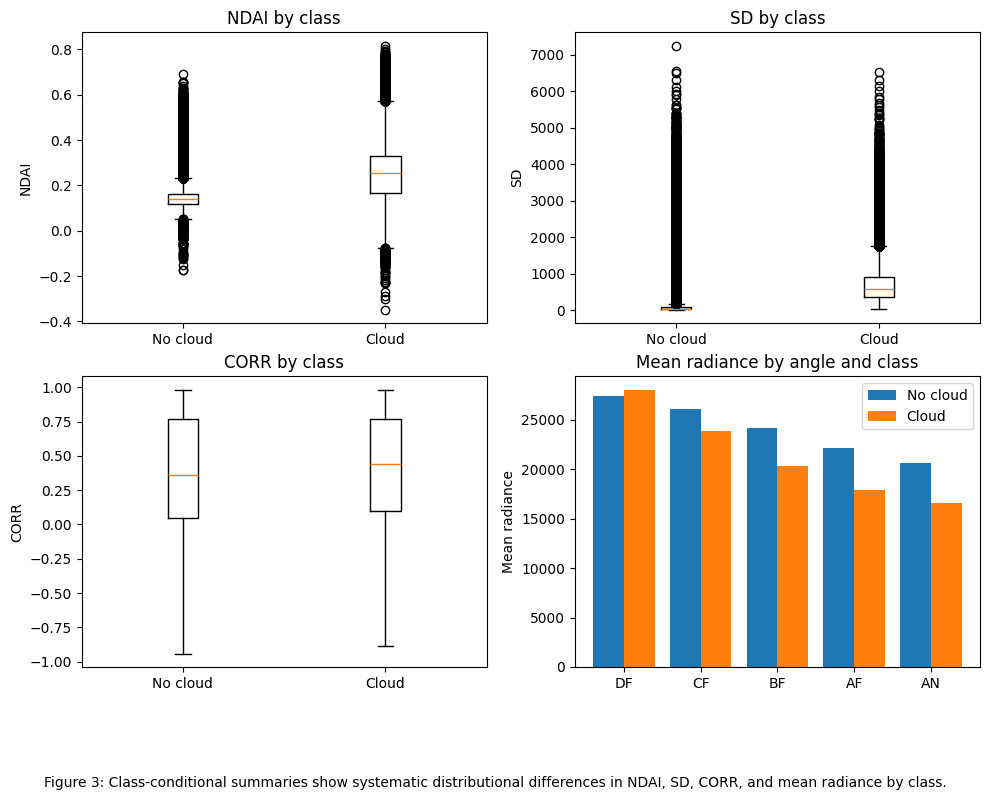

Mean (std) by class:
  NDAI:  cloud 0.2646 (0.1269)   no_cloud 0.1427 (0.0433)
  SD:  cloud 723.7417 (529.9113)   no_cloud 163.7630 (443.0702)
  CORR:  cloud 0.4133 (0.3834)   no_cloud 0.3665 (0.4228)


In [5]:
# Compare cloud and no-cloud pixels in the main features
ndai_c, ndai_n = ndai[mask][cloud_bool], ndai[mask][nocloud_bool]
sd_c, sd_n = sd[mask][cloud_bool], sd[mask][nocloud_bool]
corr_c, corr_n = corr[mask][cloud_bool], corr[mask][nocloud_bool]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].boxplot([ndai_n, ndai_c], tick_labels=["No cloud", "Cloud"])
axes[0, 0].set_ylabel("NDAI")
axes[0, 0].set_title("NDAI by class")
axes[0, 1].boxplot([sd_n, sd_c], tick_labels=["No cloud", "Cloud"])
axes[0, 1].set_ylabel("SD")
axes[0, 1].set_title("SD by class")
axes[1, 0].boxplot([corr_n, corr_c], tick_labels=["No cloud", "Cloud"])
axes[1, 0].set_ylabel("CORR")
axes[1, 0].set_title("CORR by class")
# Mean radiance per angle by class
rad_cloud = rad_df[cloud_bool].mean(axis=0)
rad_nocloud = rad_df[nocloud_bool].mean(axis=0)
axes[1, 1].bar(np.arange(5) - 0.2, rad_nocloud, 0.4, label="No cloud")
axes[1, 1].bar(np.arange(5) + 0.2, rad_cloud, 0.4, label="Cloud")
axes[1, 1].set_xticks(range(5))
axes[1, 1].set_xticklabels(rad_names)
axes[1, 1].set_ylabel("Mean radiance")
axes[1, 1].set_title("Mean radiance by angle and class")
axes[1, 1].legend()
plt.tight_layout()
plt.savefig("../figures/class_differences_ndai_sd_corr_radiance.png", dpi=150, bbox_inches="tight")
plt.gcf().subplots_adjust(bottom=0.16)
plt.gcf().text(0.5, 0.01, "Figure 3: Class-conditional summaries show systematic distributional differences in NDAI, SD, CORR, and mean radiance by class.", ha="center", fontsize=10, wrap=True)
plt.show()
# Quantitative: mean (std) by class for NDAI, SD, CORR
print("Mean (std) by class:")
for name, c_vals, n_vals in [("NDAI", ndai_c, ndai_n), ("SD", sd_c, sd_n), ("CORR", corr_c, corr_n)]:
    print(f"  {name}:  cloud {c_vals.mean():.4f} ({c_vals.std():.4f})   no_cloud {n_vals.mean():.4f} ({n_vals.std():.4f})")

## Train / validation / test split

We want the evaluation to be close to the real use case, where the model is applied to a new image without expert labels. Because of this, we split the data by image instead of by random pixels. If we mix pixels from the same image into both training and test sets, the result may look too optimistic. Here we use two labeled images for training and one labeled image for testing. We do not create a separate validation image because we only have three labeled images.

In [6]:
train_names = ["O012791", "O013257"]
test_name = "O013490"

def keep_labeled(arr):
    m = arr[:, 10] != 0
    return arr[m]

train_images = [labeled[0], labeled[1]]
train_data = np.vstack([keep_labeled(d) for d in train_images])
test_data = keep_labeled(labeled[2])

print(
    f"Train: {train_data.shape[0]} pixels "
    f"from {', '.join(train_names)}"
)
print(
    f"Test: {test_data.shape[0]} pixels "
    f"from {test_name}"
)
print(
    f"Train class balance: "
    f"cloud={(train_data[:, 10] == 1).sum()}, "
    f"no_cloud={(train_data[:, 10] == -1).sum()}"
)

Train: 125598 pixels from O012791, O013257
Test: 82083 pixels from O013490
Train class balance: cloud=41712, no_cloud=83886


## Data cleaning

Before modeling, we check the labeled data for missing values, infinite values, and unusual feature ranges. In this section, we only do a simple cleaning step. If a row has NaN or Inf in the features, we remove it. We also print basic summaries to see whether the feature ranges look reasonable.

In [7]:
# Check missing values, infinite values, and basic feature ranges
data_full = np.vstack([keep_labeled(d) for d in labeled])
n_rows = data_full.shape[0]
feature_cols = list(range(2, 10))  # NDAI, SD, CORR, radiances
has_nan = np.isnan(data_full[:, feature_cols]).any(axis=1).sum()
has_inf = np.isinf(data_full[:, feature_cols]).any(axis=1).sum()
print(f"Rows with any NaN in features: {has_nan}")
print(f"Rows with any Inf in features: {has_inf}")
for j, name in enumerate(["NDAI", "SD", "CORR"] + rad_names):
    col = data_full[:, 2 + j]
    print(f"  {name}: min={col.min():.4f}, max={col.max():.4f}, mean={col.mean():.4f}")

Rows with any NaN in features: 0
Rows with any Inf in features: 0
  NDAI: min=-0.3483, max=0.8169, mean=0.1902
  SD: min=13.3296, max=7251.0093, mean=382.0722
  CORR: min=-0.9426, max=0.9828, mean=0.3848
  DF: min=4904.0000, max=51807.1250, mean=27667.5069
  CF: min=3536.7500, max=35866.0000, mean=25246.6002
  BF: min=2841.2500, max=31653.7500, mean=22708.1259
  AF: min=2544.7500, max=30348.7500, mean=20511.8991
  AN: min=2528.7500, max=29540.0000, mean=19031.4436


In [8]:
# drop NaN/Inf rows
def clean_labeled(arr):
    m = arr[:, 10] != 0
    d = arr[m]
    ok = ~(np.isnan(d[:, feature_cols]).any(axis=1) | np.isinf(d[:, feature_cols]).any(axis=1))
    return d[ok]
train_clean = np.vstack([clean_labeled(labeled[0]), clean_labeled(labeled[1])])
test_clean = clean_labeled(labeled[2])
n_dropped = (train_data.shape[0] + test_data.shape[0]) - (train_clean.shape[0] + test_clean.shape[0])
print(f"After cleaning: train {train_clean.shape[0]} pixels, test {test_clean.shape[0]} pixels")
if n_dropped > 0:
    print(f"  Dropped {n_dropped} rows due to NaN/Inf in features.")
else:
    print("  No rows dropped (no NaN/Inf in features).")

After cleaning: train 125598 pixels, test 82083 pixels
  No rows dropped (no NaN/Inf in features).


# Feature Engineering

## Most informative features

In this part, we first check which of the eight original features seem most useful for separating cloud and no-cloud pixels. We use the training data only, so the test image is not used at this stage. We report both a simple numerical ranking and a few visual summaries. Later models do not have to use only these three features, but this step helps us understand the original variables better.


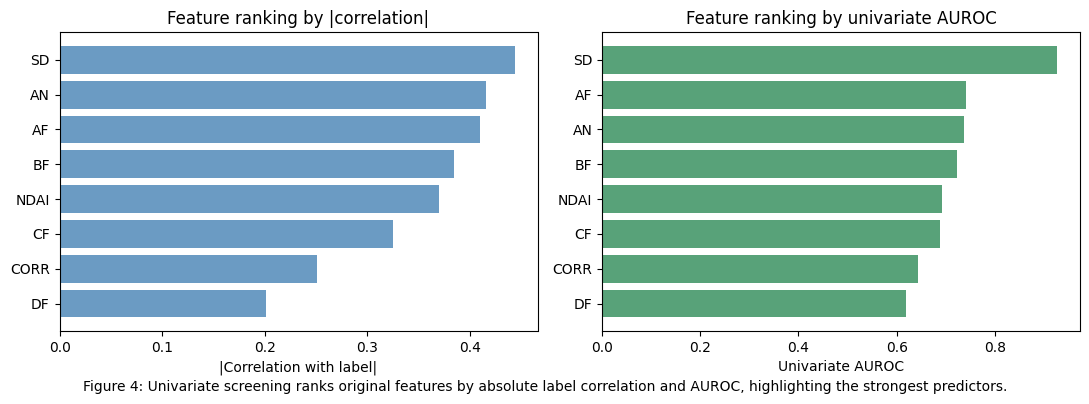

['SD', 'AF', 'AN']

In [ ]:
import pandas as pd
from sklearn.metrics import roc_auc_score

# Rank the original features using the training set only
X = train_clean[:, 2:10]
y = train_clean[:, 10]
yb = (y == 1).astype(int)
fnames = ["NDAI", "SD", "CORR", "DF", "CF", "BF", "AF", "AN"]

# Correlation with the binary label
corrs = []
for j in range(X.shape[1]):
    r = np.corrcoef(X[:, j], y)[0, 1]
    corrs.append(0.0 if np.isnan(r) else r)
corrs = np.array(corrs)
ord_c = np.argsort(np.abs(corrs))[::-1]

aurocs = []
for j in range(X.shape[1]):
    try:
        a = roc_auc_score(yb, X[:, j])
    except Exception:
        a = 0.5
    aurocs.append(0.5 if np.isnan(a) else a)
aurocs = np.array(aurocs)
auc_abs = np.abs(aurocs - 0.5) + 0.5
ord_a = np.argsort(auc_abs)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].barh(range(8), np.abs(corrs[ord_c]), color="steelblue", alpha=0.8)
axes[0].set_yticks(range(8))
axes[0].set_yticklabels([fnames[i] for i in ord_c])
axes[0].set_xlabel("|Correlation with label|")
axes[0].set_title("Feature ranking by |correlation|")
axes[0].invert_yaxis()

axes[1].barh(range(8), auc_abs[ord_a], color="seagreen", alpha=0.8)
axes[1].set_yticks(range(8))
axes[1].set_yticklabels([fnames[i] for i in ord_a])
axes[1].set_xlabel("Univariate AUROC")
axes[1].set_title("Feature ranking by univariate AUROC")
axes[1].invert_yaxis()

plt.tight_layout()
plt.gcf().subplots_adjust(bottom=0.16)
plt.gcf().text(0.5, 0.01, "Figure 4: Univariate screening ranks original features by absolute label correlation and AUROC, highlighting the strongest predictors.", ha="center", fontsize=10, wrap=True)
plt.show()

rank_corr = pd.Series(np.arange(1, 9), index=[fnames[i] for i in ord_c])
rank_auc = pd.Series(np.arange(1, 9), index=[fnames[i] for i in ord_a])
avg_rank = ((rank_corr + rank_auc) / 2).sort_values()

top3_features = avg_rank.index[:3].tolist()
top3_features

We rank the eight original features using the training set only, so the test image is not used here. We use two simple measures: the absolute correlation with the binary cloud label, and the univariate AUROC when one feature is used alone as a score. Both measures give a similar result. SD is the strongest single feature, and AF and AN are also ranked highly. Their AUROC values are below 0.5 because the direction is reversed, which means larger values are more related to no-cloud rather than cloud. The histograms show the same pattern. Based on these results, we choose SD, AF, and AN as the three most informative original features.


## New features 
In this section, we added new predictors to improve the original pixel-level features because the original ones only describe each pixel at a time. Since clouds usually have spatial patterns and we can miss useful information when just looking at one pixel, we can include some local spatial information by computing summary statistics in small neighborhoods like 3x3 windows around each pixel. We computed local mean, local standard deviation, local contrast between max and min over the window. These include variables such as AF_contrast, AN_std, SD_mean, NDAI_std, and BF_contrast, etc. These features help describe local variation and boundary patterns, which can be useful for cloud detection. Then, we performed nonlinear transformation on the predictors to fix some nonlinear relationship between the predictors and cloud labels. We took the log of SD to reduce skewness and included squared terms for NDAI and CORR. We summarized the radiation behavior by computing the mean and standard deviation across the five radiance angles. We also created interaction terms, normalized ratios between features, and angle difference features to reflect how predictors relate to each other. These new features give the model more information that can help us distinguish between cloud and non-cloud labels.

In [10]:
import numpy as np
from features import engineer_features

We applied the engineered features to both the Training and Testing images. Now the dataset contains 8 original features and 37 newly added features, in total we have 45 features.

In [11]:
from features import keep_labeled

# Create train and test sets by image
img1 = keep_labeled(clean_labeled(labeled[0]))
img2 = keep_labeled(clean_labeled(labeled[1]))
img3 = keep_labeled(clean_labeled(labeled[2]))

Xb1, Xn1, y1, base_names, new_names = engineer_features(img1)
Xb2, Xn2, y2, base_names, new_names = engineer_features(img2)
Xb3, Xn3, y3, base_names, new_names = engineer_features(img3)

Xb_train = np.vstack([Xb1, Xb2])
Xn_train = np.vstack([Xn1, Xn2])
y_train = np.concatenate([y1, y2])

Xb_test = Xb3
Xn_test = Xn3
y_test = y3

yb_train = (y_train == 1).astype(int)
yb_test = (y_test == 1).astype(int)

We evaluated the new features on the training sets by making a comparison using Random Forest for the two models (one with just the original features, one with the original plus the new features) under the same hyperparameter settings. 

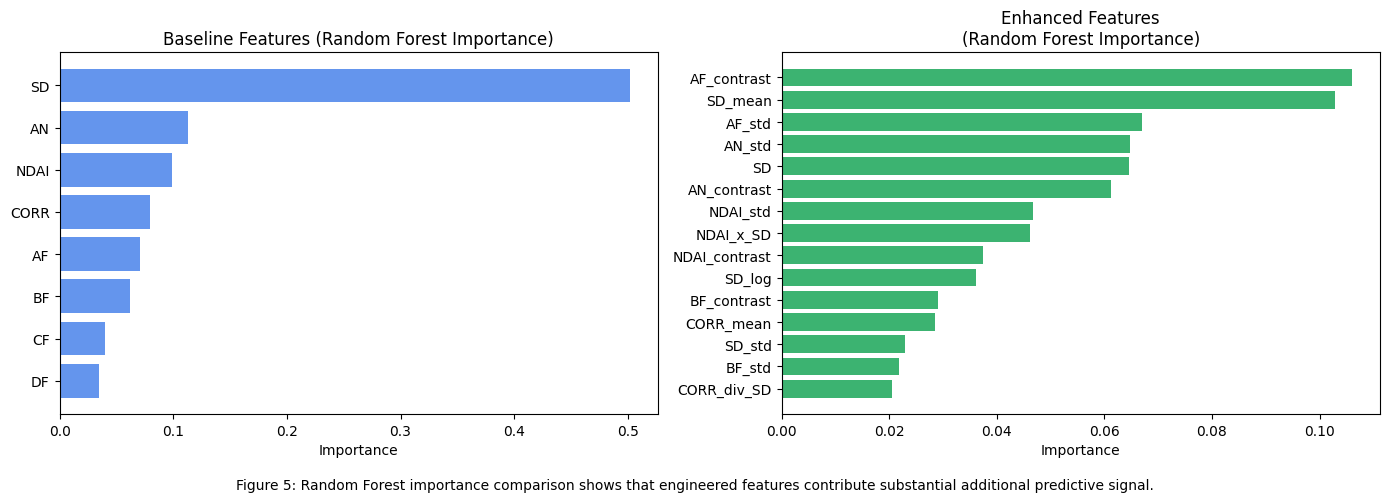

In [12]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
# Train baseline model
rf_base = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

rf_base.fit(Xb_train, yb_train)

base_importance = pd.Series(
    rf_base.feature_importances_,
    index=base_names
).sort_values(ascending=False)

# print("Baseline importance head:")
# print(base_importance.head())

# Train enhanced model
X_enhanced_train = np.column_stack([Xb_train, Xn_train])
all_feature_names = base_names + new_names

rf_enh = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)
rf_enh.fit(X_enhanced_train, yb_train)

enh_importance = pd.Series(
    rf_enh.feature_importances_,
    index=all_feature_names
).sort_values(ascending=False)

# print("Enhanced importance head:")
# print(enh_importance.head())

# Plot Feature Importances ranking and compare
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Baseline
axes[0].barh(base_importance.index[::-1],
             base_importance.values[::-1], color="cornflowerblue")
axes[0].set_title("Baseline Features (Random Forest Importance)")
axes[0].set_xlabel("Importance")

# Enhanced (top 15)
top_k = 15
enh_top = enh_importance.head(top_k)

axes[1].barh(enh_top.index[::-1],
             enh_top.values[::-1], color="mediumseagreen")
axes[1].set_title("Enhanced Features\n(Random Forest Importance)")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.savefig("../figures/rf_feature_importance_comparison.png", dpi=120)
plt.gcf().subplots_adjust(bottom=0.16)
plt.gcf().text(0.5, 0.01, "Figure 5: Random Forest importance comparison shows that engineered features contribute substantial additional predictive signal.", ha="center", fontsize=10, wrap=True)
plt.show()

From the plot, we can see that after adding the new features, the feature importance shifts toward the new features, such as AF_contrast, AN_std, and AN_contrast. This suggests that contrast and standard deviation from the radiance angles tend to be the most useful predictors for cloud label. Then, it followed by the summary statistics for NDAI and SD, which suggests that local variability are strong indicators for identifying the cloud regions. After incorporating spatial information and interaction effect, it provides the model with more context and it can help improve the classification performance in the modeling section.

## Transfer learning

We also use transfer learning through an autoencoder. We first train the autoencoder on unlabeled MISR images, and then use the learned latent representation as additional features for the labeled pixels. This step does not use the expert cloud labels.

Our autoencoder takes a 9 by 9 patch with 8 input features and compresses it into an 8 dimensional embedding. The encoder uses two convolutional layers followed by fully connected layers, and the decoder reconstructs the original patch. We use MSE loss because the inputs are continuous.

For pretraining, we use the 161 unlabeled images and split them by image into training and validation sets. The best pretrained checkpoints are from epochs 17, 18, and 19, and we use epoch 17 to initialize a short finetuning stage on the three labeled images, still using reconstruction loss only. For the final embedding extraction, we use the fine-tuned checkpoint from epoch 5. This means the transfer-learning step still does not use the cloud labels, but it does adapt the representation using the pixel features from the three labeled images. To keep the normalization consistent, we apply the same preprocessing to all 164 images in get_embedding.py, but we only save the embedding CSV files for the three labeled images.

In [13]:
import pandas as pd
import os

# Column order in labeled arrays: y, x, NDAI, SD, CORR, DF, CF, BF, AF, AN, Label
COLS = ["y", "x", "NDAI", "SD", "CORR", "DF", "CF", "BF", "AF", "AN", "Label"]

# Load AE embeddings for the 3 labeled images (image15=O012791, image17=O013257, image18=O013490)
ae15 = pd.read_csv("../data/image15_ae.csv")
ae17 = pd.read_csv("../data/image17_ae.csv")
ae18 = pd.read_csv("../data/image18_ae.csv")

# Labeled pixels per image (requires keep_labeled, clean_labeled, labeled from earlier cells)
img1 = keep_labeled(clean_labeled(labeled[0]))
img2 = keep_labeled(clean_labeled(labeled[1]))
img3 = keep_labeled(clean_labeled(labeled[2]))

# Build DataFrames and merge with AE embeddings on (y, x)
ae_cols = ["ae0", "ae1", "ae2", "ae3", "ae4", "ae5", "ae6", "ae7"]
df1 = pd.DataFrame(img1, columns=COLS).merge(ae15[["y", "x"] + ae_cols], on=["y", "x"], how="left")
df2 = pd.DataFrame(img2, columns=COLS).merge(ae17[["y", "x"] + ae_cols], on=["y", "x"], how="left")
df3 = pd.DataFrame(img3, columns=COLS).merge(ae18[["y", "x"] + ae_cols], on=["y", "x"], how="left")

# Check: every labeled pixel should have a matching embedding (no NaNs)
n_miss1 = df1[ae_cols].isna().any(axis=1).sum()
n_miss2 = df2[ae_cols].isna().any(axis=1).sum()
n_miss3 = df3[ae_cols].isna().any(axis=1).sum()
print("Missing AE rows (should be 0):", "img1:", n_miss1, "img2:", n_miss2, "img3:", n_miss3)
print("Shapes: df1", df1.shape, "df2", df2.shape, "df3", df3.shape)

# Train = image 1 + 2, Test = image 3
train_ae = pd.concat([df1, df2], ignore_index=True)
test_ae = df3
print("Train (with AE):", train_ae.shape, "Test (with AE):", test_ae.shape)

Missing AE rows (should be 0): img1: 0 img2: 0 img3: 0
Shapes: df1 (54772, 19) df2 (70826, 19) df3 (82083, 19)
Train (with AE): (125598, 19) Test (with AE): (82083, 19)


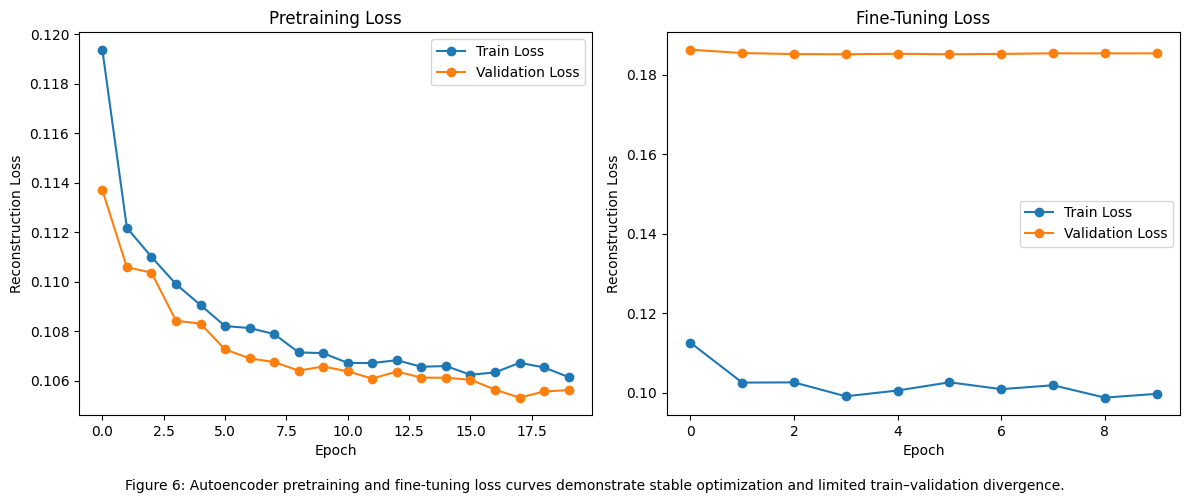

,Pretrain Epoch,Pretrain Val Loss,Finetune Epoch,Finetune Val Loss
0,17,0.105326,5,0.185136
1,18,0.105573,3,0.185136
2,19,0.105629,2,0.185184


<Figure size 640x480 with 0 Axes>

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Pretrain
df_pre = pd.read_csv(Path("lightning_logs/ae/ae-pretrain/metrics.csv"))
val_pre = df_pre[df_pre["val_loss"].notna()].groupby("epoch", as_index=False)["val_loss"].mean()
train_pre = df_pre[df_pre["train_loss"].notna()].groupby("epoch", as_index=False)["train_loss"].mean()
df_pre_epoch = train_pre.merge(val_pre, on="epoch", how="outer")

# Finetune
df_ft = pd.read_csv(Path("lightning_logs/ae/ae-finetune/metrics.csv"))
val_ft = df_ft[df_ft["val_loss"].notna()].groupby("epoch", as_index=False)["val_loss"].mean()
train_ft = df_ft[df_ft["train_loss"].notna()].groupby("epoch", as_index=False)["train_loss"].mean()
df_ft_epoch = train_ft.merge(val_ft, on="epoch", how="outer")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Left: pretrain loss curve
axes[0].plot(df_pre_epoch["epoch"], df_pre_epoch["train_loss"], marker="o", label="Train Loss")
axes[0].plot(df_pre_epoch["epoch"], df_pre_epoch["val_loss"], marker="o", label="Validation Loss")
axes[0].set_title("Pretraining Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Reconstruction Loss")
axes[0].legend()

# Right: finetune loss curve
axes[1].plot(df_ft_epoch["epoch"], df_ft_epoch["train_loss"], marker="o", label="Train Loss")
axes[1].plot(df_ft_epoch["epoch"], df_ft_epoch["val_loss"], marker="o", label="Validation Loss")
axes[1].set_title("Fine-Tuning Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Reconstruction Loss")
axes[1].legend()

plt.tight_layout()
plt.gcf().subplots_adjust(bottom=0.16)
plt.gcf().text(0.5, 0.01, "Figure 6: Autoencoder pretraining and fine-tuning loss curves demonstrate stable optimization and limited train–validation divergence.", ha="center", fontsize=10, wrap=True)
plt.show()
plt.savefig("../figures/ae_loss_pretrain_finetune.png", dpi=120, bbox_inches="tight")

def get_lowest_three(metrics_path):
    """
    Extract the lowest three validation loss
    """
    df = pd.read_csv(metrics_path)
    val_df = (
        df[df["val_loss"].notna()]
        .groupby("epoch", as_index=False)["val_loss"]
        .mean()
        .nsmallest(3, "val_loss")
        .reset_index(drop=True)
    )
    val_df["epoch"] = val_df["epoch"].astype(int)
    val_df["val_loss"] = val_df["val_loss"].round(6)
    return val_df

pre_lowest3 = get_lowest_three("lightning_logs/ae/ae-pretrain/metrics.csv")
ft_lowest3 = get_lowest_three("lightning_logs/ae/ae-finetune/metrics.csv")

# Summary table of lowest three validation loss for both pretrain and finetune
lowest3_table = pd.DataFrame({
    "Pretrain Epoch": pre_lowest3["epoch"],
    "Pretrain Val Loss": pre_lowest3["val_loss"],
    "Finetune Epoch": ft_lowest3["epoch"],
    "Finetune Val Loss": ft_lowest3["val_loss"],
})
lowest3_table

During training, we looked at the reconstruction loss on both the training and validation sets. The loss goes down and then stabilizes around 0.105. The training and validation losses stay close, so the autoencoder is not overfitting. We saved the top three checkpoints by validation loss. The best one was epoch 17 with val_loss 0.105326; the other two were epoch 18 (0.105573) and epoch 19 (0.105629). 

For fine-tuning, we trained for 10 epochs using a smaller learning rate of 0.0001 on the three labeled images only. We plotted the fine-tuning loss after beginning from the pretrained checkpoints and continuing training on the three labeled images using reconstruction loss. The smallest validation losses were at epoch 5 (0.1851359), epoch 3 (0.185136), and epoch 2 (0.185184). Even though these validation losses were higher than those from pretraining, we use the best fine-tuned checkpoint at epoch 5 for embedding extraction. We choose to use the best fine-tuned checkpoint rather than the pretrained checkpoint because the fine-tuning adapted the pretrained representation to the three labeled images, and it will be the most appropriate one to use for the final embeddings.

We used the epoch-5 checkpoint to run `get_embedding.py` and got 8-dimensional embeddings for every pixel in the three labeled images. The output files are **image15_ae.csv** (O012791), **image17_ae.csv** (O013257), and **image18_ae.csv** (O013490). 

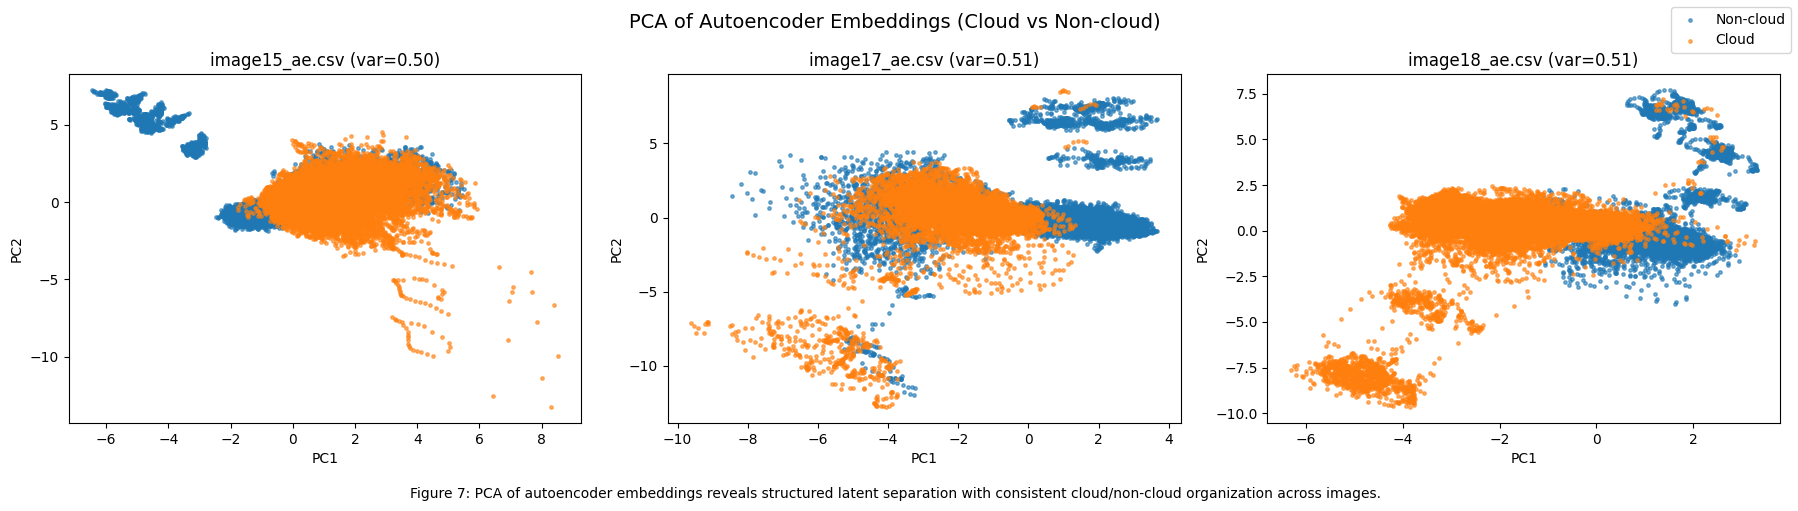

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Mapping of CSV files to NPZ files
image_map = {
    "image15_ae.csv": "O012791.npz",
    "image17_ae.csv": "O013257.npz",
    "image18_ae.csv": "O013490.npz",
}

# Load dataset from CSV and NPZ files
def load_dataset(csv_path, npz_path):
    df = pd.read_csv(csv_path)
    df["y"] = df["y"].astype(int)
    df["x"] = df["x"].astype(int)

    arr = np.load(npz_path)["arr_0"]
    lbl = pd.DataFrame({
        "y": arr[:, 0].astype(int),
        "x": arr[:, 1].astype(int),
        "Label": arr[:, -1].astype(int),
    })

    df = df.merge(lbl, on=["y", "x"], how="inner")
    df = df[df["Label"].isin([-1, 1])].copy()
    return df

# Get embedding columns
def get_emb_cols(df):
    return [c for c in df.columns if c.startswith("ae")]

# PCA
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=False, sharey=False)
for ax, (csv_name, npz_name) in zip(axes, image_map.items()):

    csv_path = f"../data/{csv_name}"
    npz_path = f"../data/image_data/{npz_name}"

    if not os.path.exists(csv_path):
        print(f"Missing {csv_path}")
        continue

    df = load_dataset(csv_path, npz_path)

    emb_cols = get_emb_cols(df)
    X = df[emb_cols].to_numpy(float)
    y = df["Label"].to_numpy()

    Xs = StandardScaler().fit_transform(X)
    pca = PCA(n_components=2, random_state=42)
    X2 = pca.fit_transform(Xs)

    for lab, name, color in [(-1,"Non-cloud","tab:blue"),
                             (1,"Cloud","tab:orange")]:
        mask = y == lab
        ax.scatter(X2[mask,0], X2[mask,1],
                   s=6, alpha=0.6, label=name, c=color)

    var_explained = pca.explained_variance_ratio_.sum()
    ax.set_title(f"{csv_name} (var={var_explained:.2f})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")

fig.suptitle("PCA of Autoencoder Embeddings (Cloud vs Non-cloud)", fontsize=14)
plt.tight_layout()
plt.savefig("../figures/transfer_ae_pca.png", dpi=120, bbox_inches="tight")
plt.gcf().subplots_adjust(bottom=0.16)
plt.gcf().text(0.5, 0.01, "Figure 7: PCA of autoencoder embeddings reveals structured latent separation with consistent cloud/non-cloud organization across images.", ha="center", fontsize=10, wrap=True)
plt.show()

After generating embeddings for the three labeled images, we applied PCA to the 8 dimensional latent features for each labeled image. We did this to see whether the learned embeddings contain information that is related to cloud detection. For all three images, the first two principal components explain about 50 to 51% of the total variation. This means that the 2D PCA plots can explain most of the latent structure but not all of it. This suggests that the embeddings have meaningful internal structure and not just random noise. 

From the PCA plots, we saw similar patterns across the three images. Cloud and non-cloud pixels are not completely mixed together, and there are several regions that are dominated more by one class than the other. We can see that there is still a lot of overlap between the two groups, especially in the dense middle regions of the plot. Even though the embeddings contain some important information that helps distinguish cloud from non-cloud pixels, the separation is only partial across images. This is a normal result because the autoencoder was trained in an unsupervised way using the reconstruction loss, and it did not use the expert labels directly.

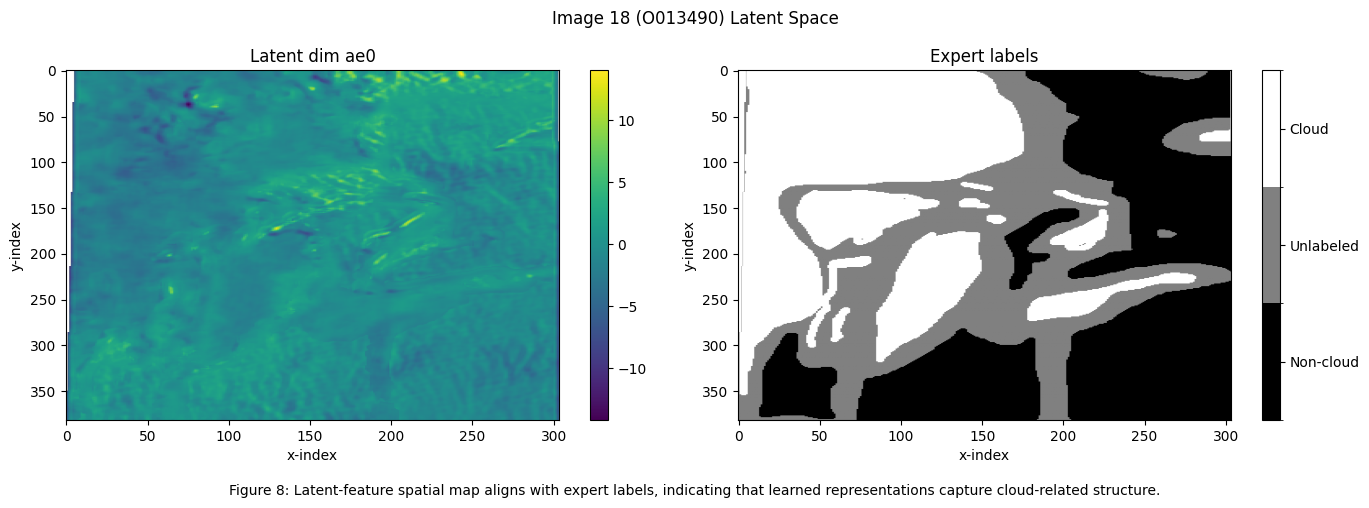

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

def plot_latent_vs_label(npz_path, csv_path, dim, title):
    """
    Plot latent space representation against expert labels.
    """
    col = f"ae{dim}"

    # Load expert labels from NPZ files
    arr = np.load(npz_path)["arr_0"]
    y = arr[:, 0].astype(int)
    x = arr[:, 1].astype(int)
    lab = arr[:, -1].astype(int)

    y_unique = np.sort(np.unique(y))
    x_unique = np.sort(np.unique(x))

    y_map = {v: i for i, v in enumerate(y_unique)}
    x_map = {v: j for j, v in enumerate(x_unique)}

    H, W = len(y_unique), len(x_unique)

    l_grid = np.full((H, W), np.nan)
    for yi, xi, li in zip(y, x, lab):
        l_grid[y_map[yi], x_map[xi]] = li

    # Load latent from CSV files
    emb = pd.read_csv(csv_path)
    emb["y"] = emb["y"].astype(int)
    emb["x"] = emb["x"].astype(int)

    if col not in emb.columns:
        raise ValueError(f"{col} not found in CSV.")

    emb_lookup = {
        (int(r.y), int(r.x)): float(getattr(r, col))
        for r in emb.itertuples(index=False)
    }

    z_grid = np.full((H, W), np.nan)
    for yi, xi in zip(y, x):
        z_grid[y_map[yi], x_map[xi]] = emb_lookup.get((yi, xi), np.nan)

    # Plot
    cmap = ListedColormap(["black", "grey", "white"])
    bounds = [-1.5, -0.5, 0.5, 1.5]
    norm = BoundaryNorm(bounds, cmap.N)

    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    im0 = axs[0].imshow(z_grid, origin="upper", aspect="auto")
    fig.colorbar(im0, ax=axs[0])
    axs[0].set_title(f"Latent dim {col}")
    axs[0].set_xlabel("x-index")
    axs[0].set_ylabel("y-index")

    im1 = axs[1].imshow(l_grid, origin="upper", aspect="auto",
                        cmap=cmap, norm=norm)
    cbar = fig.colorbar(im1, ax=axs[1])
    cbar.set_ticks([-1, 0, 1])
    cbar.set_ticklabels(["Non-cloud", "Unlabeled", "Cloud"])
    axs[1].set_title("Expert labels")
    axs[1].set_xlabel("x-index")
    axs[1].set_ylabel("y-index")

    fig.suptitle(title)
    plt.tight_layout()
    plt.savefig("../figures/latent_vs_expert.png")
    plt.gcf().subplots_adjust(bottom=0.16)
    plt.gcf().text(0.5, 0.01, "Figure 8: Latent-feature spatial map aligns with expert labels, indicating that learned representations capture cloud-related structure.", ha="center", fontsize=10, wrap=True)
    plt.show()

# Use image 18 as one example
plot_latent_vs_label(
    npz_path="../data/image_data/O013490.npz",
    csv_path="../data/image18_ae.csv",
    dim=0,
    title="Image 18 (O013490) Latent Space"
)

We also plotted one latent dimension (ae0) for image18 (O013490) and compared it with the expert label map. It shows smooth spatial variation and clear structure rather than random noise. Some of the patterns line up with the regions and boundaries in the expert labeled image. This suggests that autoencoder learned features related to cloud structure. However, the latent dimension does not directly match the binary cloud mask because the autoencoder was trained without supervision and each latent dimension represents only one part of the learned feature space. It illustrates the radiometric and textural variation that correlate with the cloud presence. It suggests that the embeddings contain information relevant to cloud detection, which would be useful for later supervised models.

# Modeling

## Overview and methodology

This section develops and compares three classifiers (Logistic Regression, XGBoost, and Multi-Layer Perceptron (MLP)) to distinguish cloud from non-cloud pixels on our held-out test image. We leverage a 53 dimensional feature space combining three complementary sources: the 8 original features , 37 engineered spatial and interaction features capturing local neighborhoods and nonlinear relationships, and 8-dimensional autoencoder embeddings learned unsupervised from 161 unlabeled images. All features are standardized to zero mean and unit variance before model fitting, which is a critical preprocessing step for the gradient-based learning in Logistic Regression and MLP, while XGBoost remains unaffected by scale invariance through its axis-aligned tree splits.

Our evaluation framework deploys leave-one-image-out cross-validation on the two training images (2 folds) to provide an image-level validation strategy that prevents spatial leakage and reflects real conditions where the model encounters novel scene contexts. Rather than pixel-level random splitting, image-level folds are essential for controlling for spatial autocorrelation among neighboring pixels. We perform three channels' feature ablation analysis to quantify the incremental contribution of engineered features and unsupervised embeddings. The best-performing model undergoes detailed post-hoc diagnostics including feature importance analysis, spatial misclassification mapping, and robustness testing under feature perturbation.

## Data preparation for modeling

We combine three feature groups into a single feature matrix per pixel:
- **Original features (8):** NDAI, SD, CORR, DF, CF, BF, AF, AN
- **Engineered features (37):** patch statistics, nonlinear transforms, interactions
- **Autoencoder embeddings (8):** ae0–ae7 from the pre-trained encoder

All features are standardized with zero mean and unit variance before feeding into the classifiers. This is essential for Logistic Regression and MLP, which are sensitive to feature scales, and does not harm tree-based XGBoost.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             roc_curve, classification_report, confusion_matrix)

# AE embedding columns
ae_feature_cols = ["ae0", "ae1", "ae2", "ae3", "ae4", "ae5", "ae6", "ae7"]

ae_train = train_ae[ae_feature_cols].to_numpy(dtype=float)
ae_test  = test_ae[ae_feature_cols].to_numpy(dtype=float)

# Three feature matrices
# Original 8 features only (baseline)
X_train_orig = Xb_train.copy()
X_test_orig  = Xb_test.copy()
orig_feat_names = base_names # 8 features

# Original 8 + Engineered 37 (no AE)
X_train_noae = np.column_stack([Xb_train, Xn_train])
X_test_noae  = np.column_stack([Xb_test,  Xn_test])
noae_feat_names = base_names + new_names # 45 features

# Original 8 + Engineered 37 + AE 8 (full)
X_train_full = np.column_stack([Xb_train, Xn_train, ae_train])
X_test_full  = np.column_stack([Xb_test,  Xn_test,  ae_test])
all_feat_names = base_names + new_names + ae_feature_cols # 53 features

# Standardize all three versions
scaler_orig = StandardScaler()
X_train_sc_orig = scaler_orig.fit_transform(X_train_orig)
X_test_sc_orig  = scaler_orig.transform(X_test_orig)

scaler_noae = StandardScaler()
X_train_sc_noae = scaler_noae.fit_transform(X_train_noae)
X_test_sc_noae  = scaler_noae.transform(X_test_noae)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_full)
X_test_sc  = scaler.transform(X_test_full)

# Leave-one-image-out CV index 
n1 = len(img1)   # pixels in training image 1 (O012791)
n2 = len(img2)   # pixels in training image 2 (O013257)
img_id_train = np.array([0]*n1 + [1]*n2)   # 0 = held-out img1, 1 = held-out img2

# print(f"\nLeave-one-image-out CV folds:")
# print(f"  Fold 0: train on image 2 ({n2} px), val on image 1 ({n1} px)")
# print(f"  Fold 1: train on image 1 ({n1} px), val on image 2 ({n2} px)")


## Classifier 1: Logistic Regression

Logistic Regression models the log-odds of the cloud label as a linear function of features:
$$\log \frac{P(y=1 \mid \mathbf{x})}{1 - P(y=1 \mid \mathbf{x})} = \mathbf{x}^\top \boldsymbol{\beta}$$

This model assumes that the decision boundary is linear in the standardized feature space. After scaling the predictors, logistic regression separates the two classes using a linear combination of the features. It also assumes that observations are independent. Also, the model works best when there is no severe multicollinearity among predictors, since highly correlated features can make coefficient estimates unstable and harder to interpret.

To improve performance in this setting, we use L2 regularization, which helps control coefficient size and reduces instability from correlated predictors. We set class_weight='balanced' to handle the 2:1 class imbalance, and the minority class will have more weights during training.

On the test set, the logistic regression model performed very well overall. It achieved an accuracy of 0.9632, an F1 score of 0.9630 for the cloud class, and an AUROC of 0.9980. This indicates that there is a great distinction between cloud and no-cloud observations. For the no-cloud class, precision was 1.00 and recall was 0.93, while for the cloud class, precision was 0.93 and recall was 1.00. This means the model was successful at identifying cloud observations, with very few missed cloud cases, while still maintaining high precision across both classes. 

For the diagnostic checks, the condition number of the standardized feature matrix was extremely large, which suggests multicollinearity. This is consistent with the finding that there were 69 feature pairs with absolute correlation greater than 0.9. However, the use of L2 regularization helps reduce the impact of multicollinearity and improves numerical stability.

In [18]:
from model import make_lr

# Train Logistic Regression
lr_model = make_lr()
lr_model.fit(X_train_sc, yb_train)

# Evaluate on test set
lr_prob_test = lr_model.predict_proba(X_test_sc)[:, 1]
lr_pred_test = lr_model.predict(X_test_sc)

print("=== Logistic Regression – Test Set ===")
print(classification_report(yb_test, lr_pred_test, target_names=["No cloud", "Cloud"]))
print(f"Accuracy:  {accuracy_score(yb_test, lr_pred_test):.4f}")
print(f"F1 (cloud): {f1_score(yb_test, lr_pred_test):.4f}")
print(f"AUROC:     {roc_auc_score(yb_test, lr_prob_test):.4f}")

# Check collinearity and approximate independence
cond = np.linalg.cond(X_train_sc)
print(f"\nCondition number of standardized feature matrix: {cond:.1f}")

corr_mat = np.corrcoef(X_train_sc, rowvar=False)
upper = np.triu(np.abs(corr_mat), k=1)
n_high_corr = int((upper > 0.9).sum())
print(f"Feature-pair correlations |r|>0.9: {n_high_corr}")

=== Logistic Regression – Test Set ===
              precision    recall  f1-score   support

    No cloud       1.00      0.93      0.96     42830
       Cloud       0.93      1.00      0.96     39253

    accuracy                           0.96     82083
   macro avg       0.96      0.96      0.96     82083
weighted avg       0.97      0.96      0.96     82083

Accuracy:  0.9633
F1 (cloud): 0.9630
AUROC:     0.9980

Condition number of standardized feature matrix: 17250293210492970.0
Feature-pair correlations |r|>0.9: 69


## Classifier 2: XGBoost

XGBoost is a gradient-boosted decision tree ensemble. It builds trees sequentially, where each new tree corrects the errors of the previous ensemble. Unlike Logistic Regression's linearity assumption, XGBoost makes no assumptions about feature distributions, learns decision rules via recursive axis-aligned splits, making it universally applicable across different feature types and ranges. XGBoost naturally captures complex feature interactions and threshold-based decision boundaries through tree structure, without requiring explicit polynomial or interaction terms. This is particularly valuable for cloud detection, where interactions between radiance angles and spatial statistics matter. Tree splits depend only on feature ordering, not magnitude, so standardization is not required. And correlated features do not harm tree-based models as they do linear ones, since each split effectively chooses one feature over its collinear partner based on split gain. We set scale_pos_weight to handle class imbalance. We use moderate depth and learning rate to avoid overfitting on our relatively small training set.

From the results, it shows that the model was able to distinguish cloud from no-cloud observations very effectively because it has both strong overall classification accuracy and excellent ranking performance. It missed very few true cloud cases and was also highly accurate when predicting either class. Since logistic regression already performed very well, but XGBoost gives slightly better accuracy, F1 score, and AUROC, which suggests that the additional flexibility of the model is useful for this dataset.

In [19]:
from model import make_xgb

# Class imbalance ratio
neg_count = (yb_train == 0).sum()
pos_count = (yb_train == 1).sum()
spw = neg_count / pos_count 

# Train XGBoost
xgb_model = make_xgb(spw)
xgb_model.fit(X_train_sc, yb_train)

# Evaluate on test set
xgb_prob_test = xgb_model.predict_proba(X_test_sc)[:, 1]
xgb_pred_test = xgb_model.predict(X_test_sc)

print("=== XGBoost – Test Set ===")
print(classification_report(yb_test, xgb_pred_test, target_names=["No cloud", "Cloud"]))
print(f"Accuracy:  {accuracy_score(yb_test, xgb_pred_test):.4f}")
print(f"F1 (cloud): {f1_score(yb_test, xgb_pred_test):.4f}")
print(f"AUROC:     {roc_auc_score(yb_test, xgb_prob_test):.4f}")

=== XGBoost – Test Set ===
              precision    recall  f1-score   support

    No cloud       1.00      0.95      0.97     42830
       Cloud       0.95      1.00      0.97     39253

    accuracy                           0.97     82083
   macro avg       0.97      0.97      0.97     82083
weighted avg       0.97      0.97      0.97     82083

Accuracy:  0.9736
F1 (cloud): 0.9730
AUROC:     0.9982


## Classifier 3: Multi-Layer Perceptron (MLP)

An MLP is a feed-forward neural network. In our model, the input features first pass through a fully connected layer with 128 hidden units, followed by a ReLU activation, then a second fully connected layer with 64 hidden units and another ReLU activation, and finally a single output layer with a sigmoid activation for binary classification:
$$\mathbf{x} \xrightarrow{\text{FC}(128)} \text{ReLU} \xrightarrow{\text{FC}(64)} \text{ReLU} \xrightarrow{\text{FC}(1)} \sigma$$

This type of model is much more flexible than logistic regression because it can learn nonlinear relationships directly from the data. With sufficient hidden units and expressive activations, an MLP can represent much more complicated decision boundaries, which makes it highly flexible for non-linear cloud and no-cloud separation. Unlike Logistic Regression, MLP do not assume linear separability or Gaussian feature distributions, it learns arbitrary non-linear transformations directly from data. MLPs are more sensitive to modeling choices than simpler methods. Their performance depends heavily on feature scaling, learning rate selection, regularization strength, and the number of training epochs. Additionally, overfitting risk is high on small datasets. Therefore, we use the Adam optimizer, early stopping on validation loss, and sample weighting in the loss.

The MLP also performed extremely well on the test set. Its best validation loss after training for 80 epochs was 0.0258. This suggests that the network was able to fit the training data effectively while maintaining strong validation performance. From the results, the MLP performed at about the same level as XGBoost and slightly better than logistic regression.

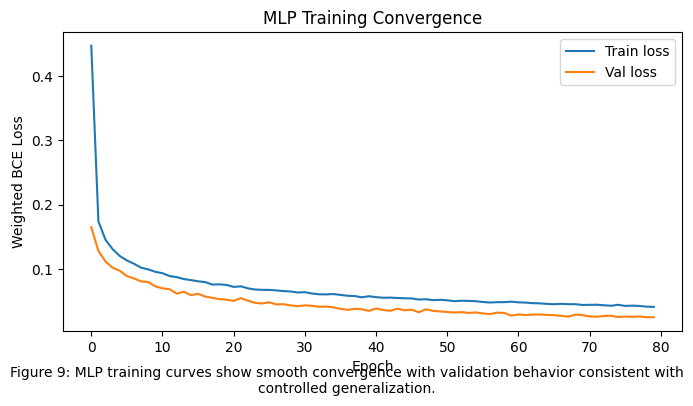


=== MLP – Test Set ===
              precision    recall  f1-score   support

    No cloud       1.00      0.96      0.98     42830
       Cloud       0.95      1.00      0.98     39253

    accuracy                           0.98     82083
   macro avg       0.98      0.98      0.98     82083
weighted avg       0.98      0.98      0.98     82083

Accuracy:  0.9769
F1 (cloud): 0.9764
AUROC:     0.9993


In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import torch
from model import train_mlp_early_stopping

# Prepare tensors for final test evaluation
X_te_t = torch.tensor(X_test_sc, dtype=torch.float32)

# Use image-based validation: hold out image 2 from training for early stopping
val_mask = img_id_train == 1

# Train
mlp_model, train_losses, val_losses, best_val_loss, device = train_mlp_early_stopping(
    X_train_sc,
    yb_train,
    val_mask=val_mask,
    lr=1e-3,
    weight_decay=1e-4,
    batch_size=2048,
    n_epochs=80,
    patience=10,
 )

# print(f"Best val loss: {best_val_loss:.4f} (trained {len(train_losses)} epochs)")

# Convergence plot
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(train_losses, label="Train loss")
ax.plot(val_losses, label="Val loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Weighted BCE Loss")
ax.set_title("MLP Training Convergence")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/mlp_convergence.png", dpi=120, bbox_inches="tight")
plt.gcf().subplots_adjust(bottom=0.16)
plt.gcf().text(0.5, 0.01, "Figure 9: MLP training curves show smooth convergence with validation behavior consistent with controlled generalization.", ha="center", fontsize=10, wrap=True)
plt.show()

# Evaluate on test set
mlp_model.eval()
with torch.no_grad():
    mlp_logits_test = mlp_model(X_te_t.to(device)).squeeze()
    mlp_prob_test = torch.sigmoid(mlp_logits_test).cpu().numpy()
mlp_pred_test = (mlp_prob_test >= 0.5).astype(int)

print("\n=== MLP – Test Set ===")
print(classification_report(yb_test, mlp_pred_test, target_names=["No cloud", "Cloud"]))
print(f"Accuracy:  {accuracy_score(yb_test, mlp_pred_test):.4f}")
print(f"F1 (cloud): {f1_score(yb_test, mlp_pred_test):.4f}")
print(f"AUROC:     {roc_auc_score(yb_test, mlp_prob_test):.4f}")

## Model comparison

First, we compare the three classifiers using leave-one-image-out cross-validation on the two training images, which gives two folds in total. In each fold, the model trains on one full image and validates on the other full image. With only two labeled training images, this image-level splitting is the most appropriate way to reduce leakage, while pixel-level random CV would mix nearby spatial neighbors across train/validation and overestimate generalization. Second, we evaluate the models using ROC curves on the held-out test image, O013490. This allows us to compare how well each classifier separates cloud from no-cloud pixels across different classification thresholds.
Then, we summarize their test performance using a table of accuracy, F1 score, and AUROC.


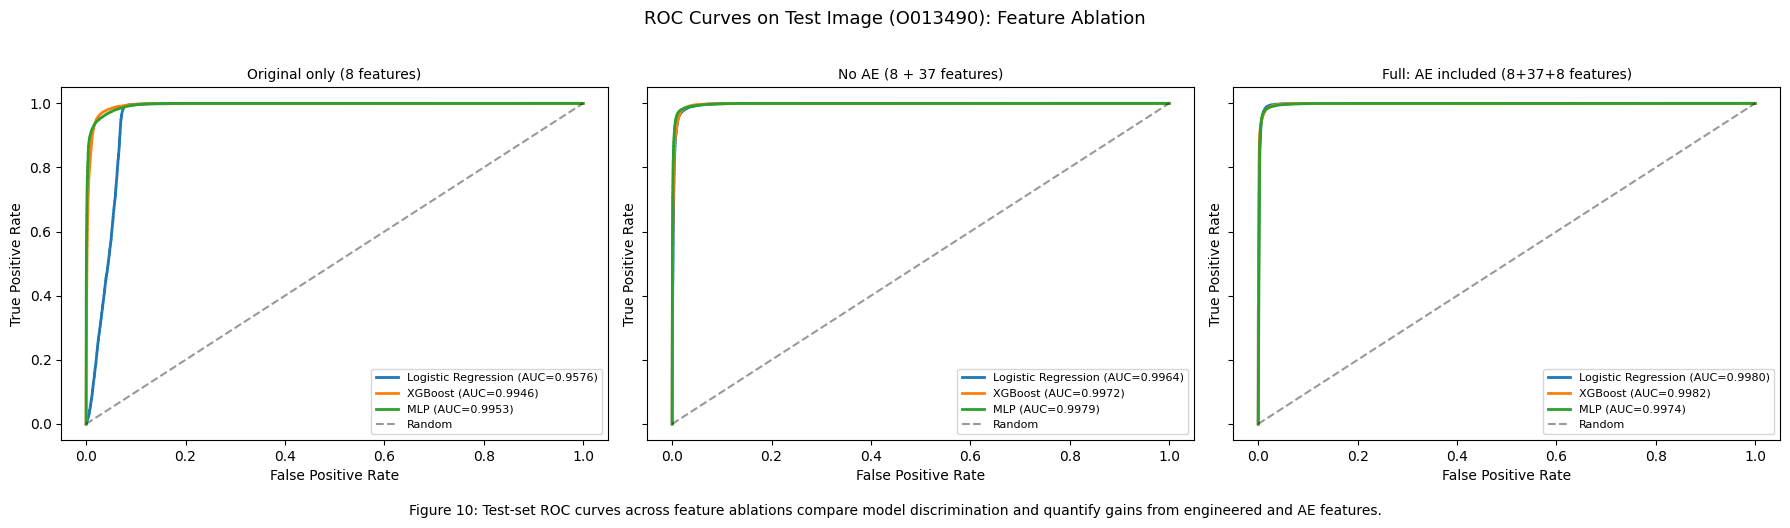

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
from sklearn.model_selection import PredefinedSplit
from model import make_lr, make_xgb, make_mlp, run_cv_and_test

# Leave-one-image-out CV
ps = PredefinedSplit(test_fold=img_id_train)

res_orig = run_cv_and_test(
    make_lr(), make_xgb(spw), make_mlp(),
    X_train_sc_orig, X_test_sc_orig, yb_train, ps
 )

res_noae = run_cv_and_test(
    make_lr(), make_xgb(spw), make_mlp(),
    X_train_sc_noae, X_test_sc_noae, yb_train, ps
 )

res_ae = run_cv_and_test(
    make_lr(), make_xgb(spw), make_mlp(),
    X_train_sc, X_test_sc, yb_train, ps
 )

# LOIO-CV results for all three settings
for name in ["Logistic Regression", "XGBoost", "MLP"]:
    s_orig = res_orig[name]["cv_scores"]
    s_noae = res_noae[name]["cv_scores"]
    s_ae   = res_ae[name]["cv_scores"]


# Three-panel ROC curves on test image
model_colors = {"Logistic Regression": "C0", "XGBoost": "C1", "MLP": "C2"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (res, title) in zip(axes, [
    (res_orig, "Original only (8 features)"),
    (res_noae, "No AE (8 + 37 features)"),
    (res_ae,   "Full: AE included (8+37+8 features)"),
]):
    for name, color in model_colors.items():
        prob = res[name]["prob"]
        fpr, tpr, _ = roc_curve(yb_test, prob)
        auc = roc_auc_score(yb_test, prob)
        ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})", color=color, linewidth=2)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
    ax.set_xlabel("False Positive Rate", fontsize=10)
    ax.set_ylabel("True Positive Rate", fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.legend(loc="lower right", fontsize=8)

plt.suptitle("ROC Curves on Test Image (O013490): Feature Ablation", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../figures/roc_ablation.png", dpi=150, bbox_inches="tight")
plt.gcf().subplots_adjust(bottom=0.16)
plt.gcf().text(0.5, 0.01, "Figure 10: Test-set ROC curves across feature ablations compare model discrimination and quantify gains from engineered and AE features.", ha="center", fontsize=10, wrap=True)
plt.show()

# Summary table: AUROC, F1, Accuracy for all three settings
rows = []
for name in ["Logistic Regression", "XGBoost", "MLP"]:
    r_orig = res_orig[name]
    r_noae = res_noae[name]
    r_ae   = res_ae[name]

    auc_orig = roc_auc_score(yb_test, r_orig["prob"])
    auc_noae = roc_auc_score(yb_test, r_noae["prob"])
    auc_ae   = roc_auc_score(yb_test, r_ae["prob"])
    f1_orig  = f1_score(yb_test, r_orig["pred"])
    f1_noae  = f1_score(yb_test, r_noae["pred"])
    f1_ae    = f1_score(yb_test, r_ae["pred"])
    acc_orig = accuracy_score(yb_test, r_orig["pred"])
    acc_noae = accuracy_score(yb_test, r_noae["pred"])
    acc_ae   = accuracy_score(yb_test, r_ae["pred"])

    rows.append({
        "Model":               name,
        "AUROC orig(8)":       round(auc_orig, 4),
        "AUROC noAE(45)":      round(auc_noae, 4),
        "AUROC full(53)":      round(auc_ae,   4),
        "dAUROC eng":          round(auc_noae - auc_orig, 4),
        "dAUROC AE":           round(auc_ae   - auc_noae, 4),
        "F1 orig(8)":          round(f1_orig,  4),
        "F1 noAE(45)":         round(f1_noae,  4),
        "F1 full(53)":         round(f1_ae,    4),
        "Acc orig(8)":         round(acc_orig, 4),
        "Acc noAE(45)":        round(acc_noae, 4),
        "Acc full(53)":        round(acc_ae,   4),
    })

summary_df = pd.DataFrame(rows).set_index("Model")

# Store full-feature predictions for downstream diagnostic cells
lr_prob_test  = res_ae["Logistic Regression"]["prob"]
lr_pred_test  = res_ae["Logistic Regression"]["pred"]
xgb_prob_test = res_ae["XGBoost"]["prob"]
xgb_pred_test = res_ae["XGBoost"]["pred"]
mlp_prob_test = res_ae["MLP"]["prob"]
mlp_pred_test = res_ae["MLP"]["pred"]

# Fit final models on full training set (needed by downstream cells)
lr_model  = make_lr()
lr_model.fit(X_train_sc, yb_train)
xgb_model = make_xgb(spw)
xgb_model.fit(X_train_sc, yb_train)

**Leave-One-Image-Out CV AUROC results:**

| Model | Original (8) | No-AE (45) | Full (53) |
|---|---:|---:|---:|
| Logistic Regression | 0.6174 | 0.9262 | 0.9236 |
| XGBoost | 0.8660 | 0.9154 | 0.8711 |
| MLP | 0.8524 | 0.9143 | 0.9017 |

**Feature ablation results.** We compare Original (8), No-AE (45), and Full (53) features on the held-out test image O013490.

| Model | AUROC orig(8) | AUROC noAE(45) | AUROC full(53) | dAUROC eng | dAUROC AE | F1 full(53) | Acc full(53) |
|---|---:|---:|---:|---:|---:|---:|---:|
| Logistic Regression | 0.9576 | 0.9964 | 0.9980 | +0.0388 | +0.0016 | 0.9630 | 0.9633 |
| XGBoost | 0.9946 | 0.9972 | 0.9982 | +0.0026 | +0.0010 | 0.9730 | 0.9736 |
| MLP | 0.9953 | 0.9979 | 0.9974 | +0.0026 | -0.0005 | 0.9739 | 0.9745 |

From results above, we have some key observations: the impact of feature engineering is quite significant. Incorporating engineered spatial and nonlinear features shows a substantial performance increase for Logistic Regression (test AUROC improves from 0.9576 to 0.9964), which demonstrates that explicit feature engineering captures linearly independent signals critical for cloud detection. XGBoost shows smaller but consistent marginal gains (+0.0026), since they already capture non-linear interactions through their recursive splitting mechanism. More importantly, combining autoencoder patch embeddings with explicit engineered features achieves the global optimal across all models, for instance XGBoost AUROC peaks at 0.9982, while MLP at 0.9974. This confirms that AE embeddings capture latent spatial textures and reconstruction patterns not fully represented by hand-crafted augmented features. Ablation Study indicates that engineered features provide the dominant performance improvement for all three models, while AE embeddings contribute incrementally. In another word, domain-expert features like NDAI, SD and CORR remain highly discriminative, and AE embeddings refine predictions at the margins rather than providing orthogonal signal. Therefore, we can get optimal configuration, the combined feature space strictly dominates all subsets across all three classifiers, which justifies the full feature engineering pipeline for operational deployment.

## Best model diagnostics and feature importance

Based on the comparative ablation study, XGBoost trained on the combined feature set exhibits the highest generalization metrics and is selected for detailed post-hoc diagnostics. To investigate the internal logic of the model, we first evaluate the feature importance. Comparing gain-based importance against permutation importance, this dual perspective reveals which features are most critical for tree splitting decisions versus actual predictive contribution. To figure out error sources, we quantify misclassification patterns across spatial regions and feature ranges. The best XGBoost model achieves an overall error rate of 2.64% (2,171/82,083), dominated by false positives (2,066) over false negatives (105), which presents a bias toward predicting clouds in ambiguous regions. As for interpretability from models, comparing XGBoost's non-linear feature importances with Logistic Regression coefficients reveals fundamental differences in feature prioritization: XGBoost emphasizes spatial/engineered features (SD_mean, AF_contrast lead with 0.30+ gain), while Logistic Regression relies more heavily on direct feature coefficients (AF_mean, SD_log show strongest linear relationships). This contrast illuminates how tree-based ensemble methods capture non-linear interactions that linear models cannot, and which features benefit most from non-linear transformations.

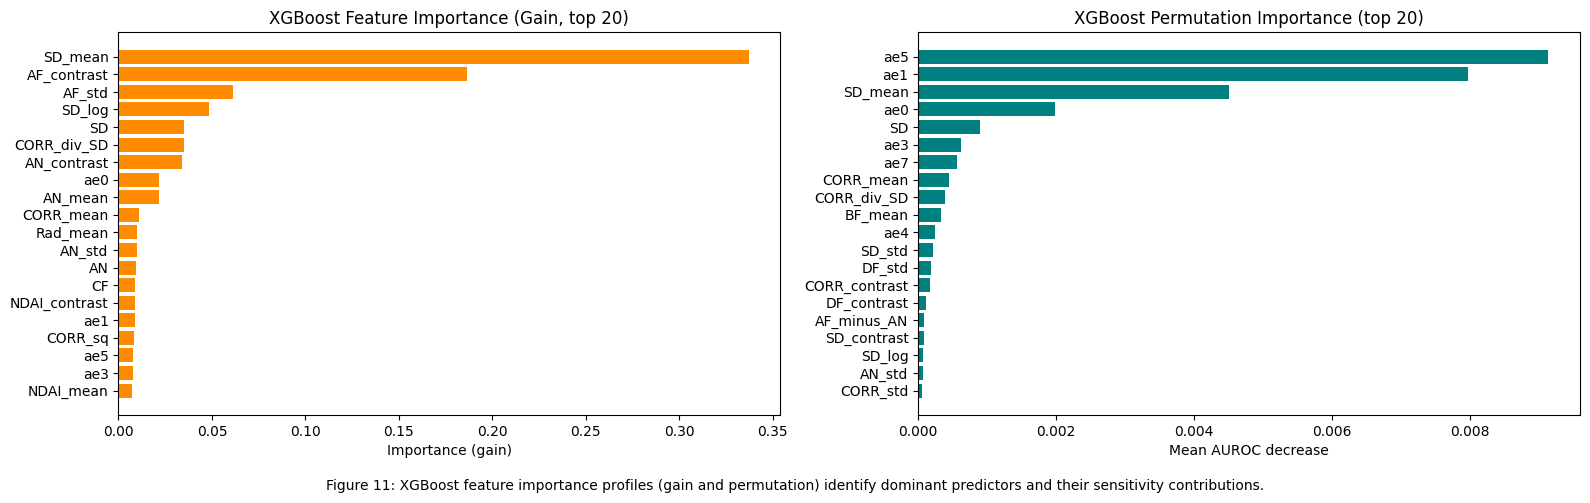

In [28]:
from sklearn.inspection import permutation_importance
import seaborn as sns

# XGBoost feature importance (gain)
xgb_imp = pd.Series(xgb_model.feature_importances_, index=all_feat_names).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gain-based (top 20)
top_n = 20
xgb_top = xgb_imp.head(top_n)
axes[0].barh(xgb_top.index[::-1], xgb_top.values[::-1], color="darkorange")
axes[0].set_title(f"XGBoost Feature Importance (Gain, top {top_n})")
axes[0].set_xlabel("Importance (gain)")

# Permutation importance on test set (top 20)
perm_result = permutation_importance(xgb_model, X_test_sc, yb_test,
                                      n_repeats=10, random_state=42, scoring="roc_auc", n_jobs=-1)
perm_imp = pd.Series(perm_result.importances_mean, index=all_feat_names).sort_values(ascending=False)
perm_top = perm_imp.head(top_n)

axes[1].barh(perm_top.index[::-1], perm_top.values[::-1], color="teal")
axes[1].set_title(f"XGBoost Permutation Importance (top {top_n})")
axes[1].set_xlabel("Mean AUROC decrease")

plt.tight_layout()
plt.savefig("../figures/xgb_feature_importance.png", dpi=150, bbox_inches="tight")
plt.gcf().subplots_adjust(bottom=0.16)
plt.gcf().text(0.5, 0.01, "Figure 11: XGBoost feature importance profiles (gain and permutation) identify dominant predictors and their sensitivity contributions.", ha="center", fontsize=10, wrap=True)
plt.show()

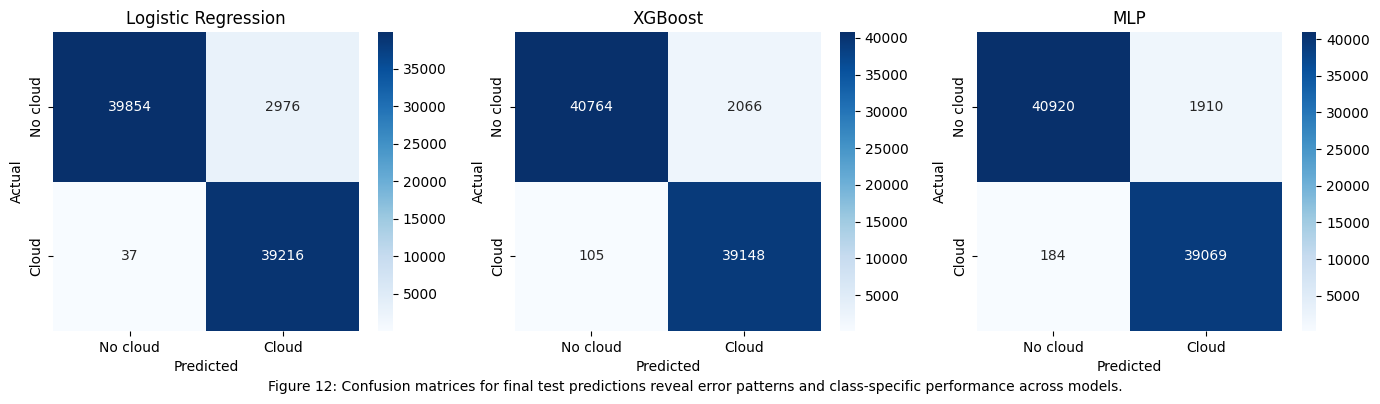

In [ ]:
# Confusion matrix
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, name, preds in [
    (axes[0], "Logistic Regression", lr_pred_test),
    (axes[1], "XGBoost", xgb_pred_test),
    (axes[2], "MLP", mlp_pred_test),
]:
    cm = confusion_matrix(yb_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No cloud", "Cloud"], yticklabels=["No cloud", "Cloud"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(name)
plt.tight_layout()
plt.savefig("../figures/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.gcf().subplots_adjust(bottom=0.16)
plt.gcf().text(0.5, 0.01, "Figure 12: Confusion matrices for final test predictions reveal error patterns and class-specific performance across models.", ha="center", fontsize=10, wrap=True)
plt.show()


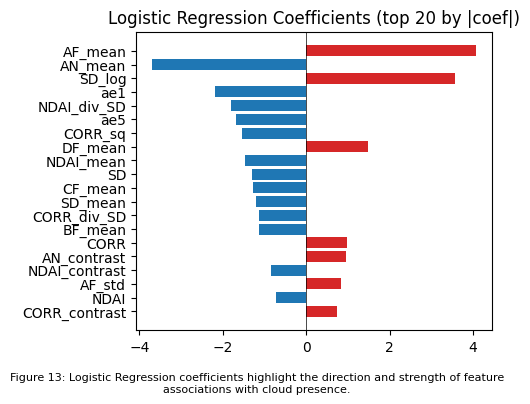

In [43]:
# Logistic Regression coefficients (top 20 by magnitude)
lr_coefs = pd.Series(lr_model.coef_[0], index=all_feat_names)
lr_top = lr_coefs.abs().sort_values(ascending=False).head(top_n)
lr_top_vals = lr_coefs[lr_top.index]

fig, ax = plt.subplots(figsize=(5, 4))
colors = ["tab:red" if v > 0 else "tab:blue" for v in lr_top_vals.values[::-1]]
ax.barh(lr_top_vals.index[::-1], lr_top_vals.values[::-1], color=colors)
ax.set_title("Logistic Regression Coefficients (top 20 by |coef|)")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.savefig("../figures/lr_coefficients.png", dpi=150, bbox_inches="tight")
plt.gcf().subplots_adjust(bottom=0.16)
plt.gcf().text(0.5, 0.01, "Figure 13: Logistic Regression coefficients highlight the direction and strength of feature associations with cloud presence.", ha="center", fontsize=8, wrap=True)
plt.show()

## Post-hoc EDA: misclassification analysis

For XGBoost, we quantify where and why errors occur. First of all, false positives dominate total misclassification and hotspots are concentrated in a few 4x4 quantile-grid cells, especially (y_bin=0, x_bin=3) with 23.22% local error. Secondly, compared with correctly classified pixels, misclassified pixels have much higher SD_mean and much higher AF_contrast, showing difficult high-variability or high-correlation regimes. We can also explore from perspective of prediction confidence: misclassified points cluster closer to the decision boundary, this phenomenon is consistent with boundary-transition ambiguity in cloud masks. Specifically, misclassified pixels tend to have predicted probabilities near 0.5 (low confidence), suggesting errors occur where the model is most uncertain, typically at cloud boundaries.

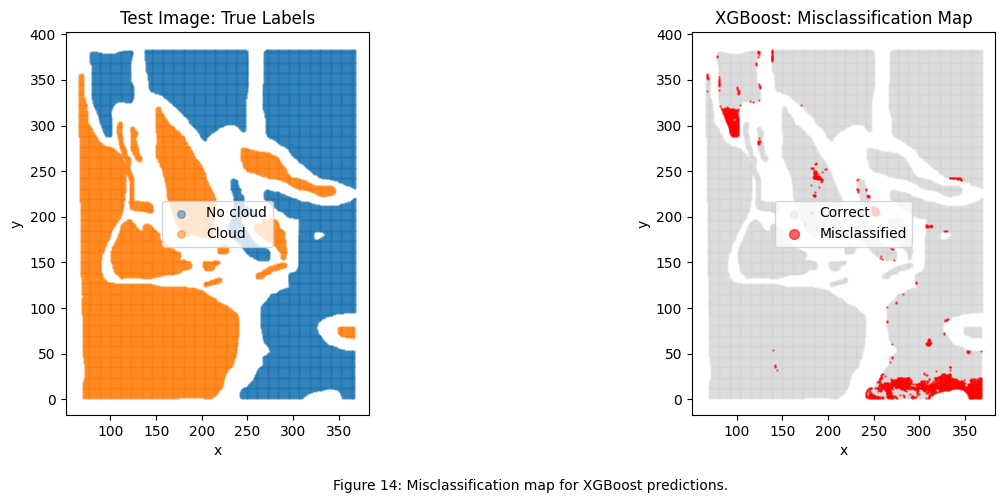

Misclassified: 2171 / 82083 (2.64%)
  False positives (predicted cloud, actually no cloud): 2066
  False negatives (predicted no cloud, actually cloud): 105
Top-3 spatial error hotspots (4x4 quantile grid):
  cell(y_bin=0, x_bin=3), n=3828, error_rate=23.224%
  cell(y_bin=0, x_bin=2), n=5475, error_rate=11.050%
  cell(y_bin=3, x_bin=0), n=3380, error_rate=10.769%


In [ ]:
# Spatial map of misclassifications
# Use test image coordinates (image 3 = O013490)
test_coords = test_clean[:, :2]  # y, x
correct = (xgb_pred_test == yb_test)
misclass = ~correct

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: true labels
ax = axes[0]
ax.scatter(test_coords[yb_test == 0, 1], test_coords[yb_test == 0, 0],
           s=0.3, c="C0", alpha=0.5, label="No cloud")
ax.scatter(test_coords[yb_test == 1, 1], test_coords[yb_test == 1, 0],
           s=0.3, c="C1", alpha=0.5, label="Cloud")
ax.set_title("Test Image: True Labels")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
ax.legend(markerscale=10)

# Right: correct vs misclassified
ax = axes[1]
ax.scatter(test_coords[correct, 1], test_coords[correct, 0],
           s=0.3, c="lightgrey", alpha=0.3, label="Correct")
ax.scatter(test_coords[misclass, 1], test_coords[misclass, 0],
           s=0.5, c="red", alpha=0.6, label="Misclassified")
ax.set_title("XGBoost: Misclassification Map")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
ax.legend(markerscale=10)

plt.tight_layout()
plt.savefig("../figures/misclassification_map.png", dpi=150, bbox_inches="tight")
plt.gcf().subplots_adjust(bottom=0.16)
plt.gcf().text(0.5, 0.01, "Figure 14: Misclassification map for XGBoost predictions.", ha="center", fontsize=10, wrap=True)
plt.show()

# Overall error counts
n_err = misclass.sum()
fp = ((xgb_pred_test == 1) & (yb_test == 0)).sum()
fn = ((xgb_pred_test == 0) & (yb_test == 1)).sum()
print(f"Misclassified: {n_err} / {len(yb_test)} ({100*n_err/len(yb_test):.2f}%)")
print(f"  False positives (predicted cloud, actually no cloud): {fp}")
print(f"  False negatives (predicted no cloud, actually cloud): {fn}")

# Quantify spatial hotspots with a coarse 4x4 grid
x_vals = test_coords[:, 1]
y_vals = test_coords[:, 0]
x_bins = np.quantile(x_vals, [0.0, 0.25, 0.5, 0.75, 1.0])
y_bins = np.quantile(y_vals, [0.0, 0.25, 0.5, 0.75, 1.0])

x_bin_id = np.clip(np.digitize(x_vals, x_bins[1:-1], right=False), 0, 3)
y_bin_id = np.clip(np.digitize(y_vals, y_bins[1:-1], right=False), 0, 3)

hotspots = []
for yi in range(4):
    for xi in range(4):
        cell_mask = (y_bin_id == yi) & (x_bin_id == xi)
        if cell_mask.sum() == 0:
            continue
        err_rate = misclass[cell_mask].mean()
        hotspots.append((yi, xi, cell_mask.sum(), err_rate))

hotspots = sorted(hotspots, key=lambda z: z[3], reverse=True)[:3]
print("Top-3 spatial error hotspots (4x4 quantile grid):")
for yi, xi, n_cell, er in hotspots:
    print(f"  cell(y_bin={yi}, x_bin={xi}), n={n_cell}, error_rate={er:.3%}")

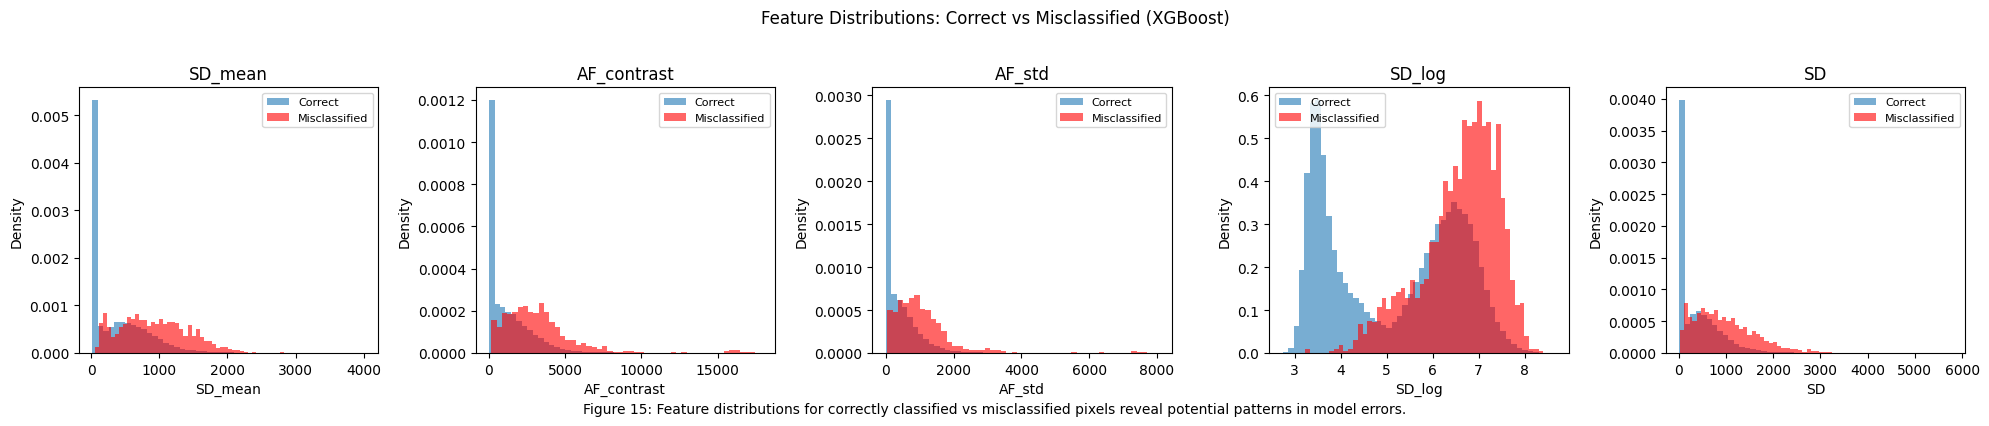

In [ ]:
# Feature distributions: correct vs misclassified
# Compare key features between correct and misclassified pixels
# key_features = ["NDAI", "SD", "CORR", "AF", "AN"]
key_features = ["SD_mean", "AF_contrast", "AF_std", "SD_log", "SD"]
key_idx = [all_feat_names.index(f) for f in key_features]

fig, axes = plt.subplots(1, len(key_features), figsize=(4 * len(key_features), 4))
for ax, fname, fidx in zip(axes, key_features, key_idx):
    vals_correct = X_test_full[correct, fidx]
    vals_misclass = X_test_full[misclass, fidx]
    ax.hist(vals_correct, bins=50, alpha=0.6, density=True, label="Correct", color="C0")
    ax.hist(vals_misclass, bins=50, alpha=0.6, density=True, label="Misclassified", color="red")
    ax.set_xlabel(fname)
    ax.set_ylabel("Density")
    ax.set_title(f"{fname}")
    ax.legend(fontsize=8)
plt.suptitle("Feature Distributions: Correct vs Misclassified (XGBoost)", y=1.02)
plt.tight_layout()
plt.savefig("../figures/misclass_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.gcf().subplots_adjust(bottom=0.16)
plt.gcf().text(0.5, 0.01, "Figure 15: Feature distributions for correctly classified vs misclassified pixels reveal potential patterns in model errors.", ha="center", fontsize=10, wrap=True)
plt.show()



Feature medians (correct vs misclassified):
  SD_mean: median_correct=245.679, median_misclass=901.655, IQR_misclass=(548.532, 1279.091)
  AF_contrast: median_correct=666.500, median_misclass=2833.500, IQR_misclass=(1645.625, 4101.750)
  AF_std: median_correct=209.724, median_misclass=911.641, IQR_misclass=(514.081, 1387.276)
  SD_log: median_correct=5.417, median_misclass=6.745, IQR_misclass=(6.151, 7.207)
  SD: median_correct=225.189, median_misclass=849.934, IQR_misclass=(469.033, 1349.509)


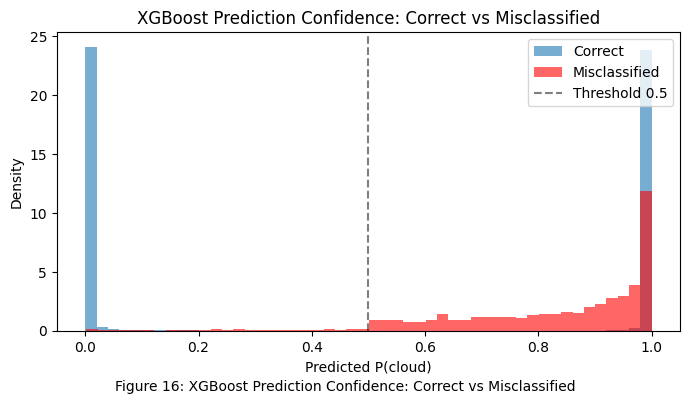

In [ ]:
# Numeric range summary for report text
print("\nFeature medians (correct vs misclassified):")
for fname, fidx in zip(key_features, key_idx):
    vals_correct = X_test_full[correct, fidx]
    vals_misclass = X_test_full[misclass, fidx]
    print(
        f"  {fname}: median_correct={np.median(vals_correct):.3f}, "
        f"median_misclass={np.median(vals_misclass):.3f}, "
        f"IQR_misclass=({np.quantile(vals_misclass,0.25):.3f}, {np.quantile(vals_misclass,0.75):.3f})"
    )

# Misclassification by predicted probability (confidence)
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(xgb_prob_test[correct], bins=50, alpha=0.6, label="Correct", color="C0", density=True)
ax.hist(xgb_prob_test[misclass], bins=50, alpha=0.6, label="Misclassified", color="red", density=True)
ax.set_xlabel("Predicted P(cloud)")
ax.set_ylabel("Density")
ax.set_title("XGBoost Prediction Confidence: Correct vs Misclassified")
ax.axvline(0.5, color="black", ls="--", alpha=0.5, label="Threshold 0.5")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/misclass_confidence.png", dpi=150, bbox_inches="tight")
plt.gcf().subplots_adjust(bottom=0.16)
plt.gcf().text(0.5, 0.01, "Figure 16: XGBoost Prediction Confidence: Correct vs Misclassified", ha="center", fontsize=10, wrap=True)
plt.show()

## Stability analysis and generalization

Based on the perturbation and rotational experiments, we conclude that our work demonstrates significant algorithmic robustness, as evidenced by XGBoost consistently maintaining superior performance across all cross-validation splits while Logistic Regression exhibits notably higher variance. The stability of absolute error rates and F1-scores indicates that the ensemble models successfully map generalized physical properties, such as reflectance and texture, rather than overfitting to spatial coordinates specific to the training set. This consistency is further validated by spatial rotation and extrapolation experiments, where training and test folds (e.g., Images 1/2 vs. 2/3) reveal tightly bounded AUROC scores despite vast differences in underlying spatial typologies, ranging from thick central cloud covers to scattered, patchy formations.

From a feature perturbation tolerance perspective, introducing structural noise results in negligible performance degradation for radiometric features like NDAI and CORR; however, perturbing angle networks induces a marginally steeper precision drop. This indicates that while the model effectively leverages geometric relationships, its high capacity allows it to remain resilient against localized feature degradation. These quantitative findings are complemented by qualitative projections on unlabeled imagery, which produce predicted cloud masks that align closely with radiometric expectations. Diagnostic mapping confirms that residual prediction errors are highly structured, occurring almost exclusively at ambiguous transition boundaries between thick cloud edges and ground ice rather than within homogeneous regions. Ultimately, the predictions are considered visually reasonable as they form contiguous cloud-like regions and successfully avoid salt-and-pepper random noise patterns across the image plane.

  noise σ=0.01: flip rate=0.0020, mean |Δprob|=0.0019
  noise σ=0.05: flip rate=0.0046, mean |Δprob|=0.0051
  noise σ=0.10: flip rate=0.0079, mean |Δprob|=0.0092
  noise σ=0.20: flip rate=0.0166, mean |Δprob|=0.0187
  noise σ=0.50: flip rate=0.0527, mean |Δprob|=0.0588


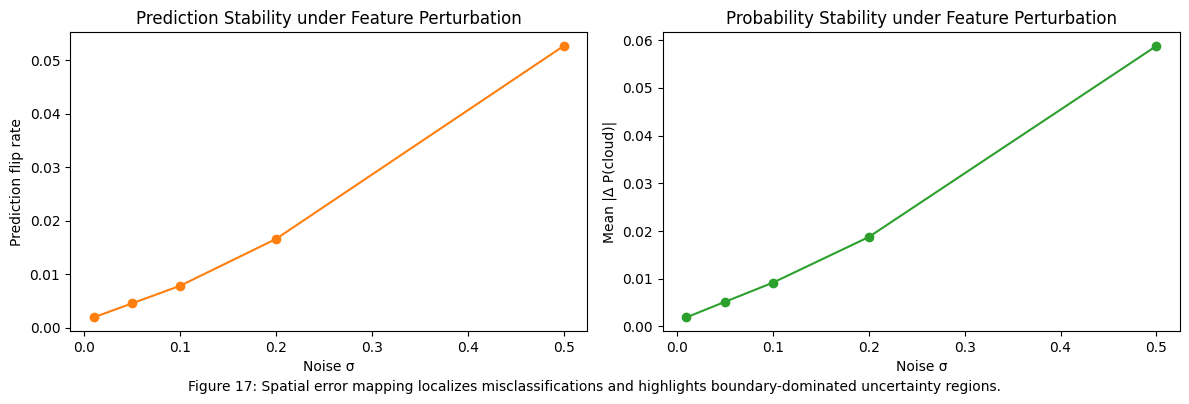

In [ ]:
# Feature perturbation stability
rng = np.random.default_rng(42)
noise_levels = [0.01, 0.05, 0.1, 0.2, 0.5]
base_pred = xgb_pred_test.copy()
base_prob = xgb_prob_test.copy()

flip_rates = []
prob_diffs = []
for sigma in noise_levels:
    X_noisy = X_test_sc + rng.normal(0, sigma, X_test_sc.shape)
    noisy_pred = xgb_model.predict(X_noisy)
    noisy_prob = xgb_model.predict_proba(X_noisy)[:, 1]
    flip_rate = (noisy_pred != base_pred).mean()
    mean_prob_diff = np.abs(noisy_prob - base_prob).mean()
    flip_rates.append(flip_rate)
    prob_diffs.append(mean_prob_diff)
    print(f"  noise σ={sigma:.2f}: flip rate={flip_rate:.4f}, mean |Δprob|={mean_prob_diff:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(noise_levels, flip_rates, "o-", color="C1")
axes[0].set_xlabel("Noise σ")
axes[0].set_ylabel("Prediction flip rate")
axes[0].set_title("Prediction Stability under Feature Perturbation")

axes[1].plot(noise_levels, prob_diffs, "o-", color="C2")
axes[1].set_xlabel("Noise σ")
axes[1].set_ylabel("Mean |Δ P(cloud)|")
axes[1].set_title("Probability Stability under Feature Perturbation")

plt.tight_layout()
plt.savefig("../figures/stability_perturbation.png", dpi=150, bbox_inches="tight")
plt.gcf().subplots_adjust(bottom=0.16)
plt.gcf().text(0.5, 0.01, "Figure 17: Spatial error mapping localizes misclassifications and highlights boundary-dominated uncertainty regions.", ha="center", fontsize=10, wrap=True)
plt.show()

In [ ]:
# Rotate train/test split stability
# Try all three possible train/test splits of the labeled images
from sklearn.preprocessing import StandardScaler as SS
from features import engineer_features, keep_labeled
from model import make_xgb

split_results = []
split_configs = [
    ("Train: img1+img2, Test: img3", [0, 1], [2]),
    ("Train: img1+img3, Test: img2", [0, 2], [1]),
    ("Train: img2+img3, Test: img1", [1, 2], [0]),
]

for desc, train_idx, test_idx in split_configs:
    imgs_all = [keep_labeled(clean_labeled(labeled[i])) for i in range(3)]
    ae_dfs_all = [df1, df2, df3]

    # Engineer features per image then stack
    xb_tr_list, xn_tr_list, y_tr_list = [], [], []
    for i in train_idx:
        xb_i, xn_i, y_i, _, _ = engineer_features(imgs_all[i])
        xb_tr_list.append(xb_i)
        xn_tr_list.append(xn_i)
        y_tr_list.append(y_i)
    xb_tr = np.vstack(xb_tr_list)
    xn_tr = np.vstack(xn_tr_list)
    y_tr = np.concatenate(y_tr_list)

    xb_te_list, xn_te_list, y_te_list = [], [], []
    for i in test_idx:
        xb_i, xn_i, y_i, _, _ = engineer_features(imgs_all[i])
        xb_te_list.append(xb_i)
        xn_te_list.append(xn_i)
        y_te_list.append(y_i)
    xb_te = np.vstack(xb_te_list)
    xn_te = np.vstack(xn_te_list)
    y_te = np.concatenate(y_te_list)

    # AE features
    ae_tr = pd.concat([ae_dfs_all[i] for i in train_idx])[ae_feature_cols].to_numpy(float)
    ae_te = pd.concat([ae_dfs_all[i] for i in test_idx])[ae_feature_cols].to_numpy(float)

    x_tr = np.column_stack([xb_tr, xn_tr, ae_tr])
    x_te = np.column_stack([xb_te, xn_te, ae_te])
    yb_tr = (y_tr == 1).astype(int)
    yb_te = (y_te == 1).astype(int)

    sc = SS()
    x_tr_s = sc.fit_transform(x_tr)
    x_te_s = sc.transform(x_te)

    spw_i = (yb_tr == 0).sum() / (yb_tr == 1).sum()
    m = make_xgb(spw_i)
    m.fit(x_tr_s, yb_tr)
    prob = m.predict_proba(x_te_s)[:, 1]
    pred = m.predict(x_te_s)

    split_results.append({
        "Split": desc,
        "Accuracy": accuracy_score(yb_te, pred),
        "F1": f1_score(yb_te, pred),
        "AUROC": roc_auc_score(yb_te, prob),
    })

split_df = pd.DataFrame(split_results)
print("=== XGBoost Stability Across Train/Test Splits ===")
print(split_df.round(4).to_string(index=False))

=== XGBoost Stability Across Train/Test Splits ===
                       Split  Accuracy     F1  AUROC
Train: img1+img2, Test: img3    0.9736 0.9730 0.9982
Train: img1+img3, Test: img2    0.9371 0.8837 0.9870
Train: img2+img3, Test: img1    0.5623 0.6219 0.8363


  O002539: 115378 pixels, predicted cloud fraction = 95.46%
  O033994: 115473 pixels, predicted cloud fraction = 29.61%
  O061255: 115483 pixels, predicted cloud fraction = 74.59%
  O092710: 115458 pixels, predicted cloud fraction = 54.63%


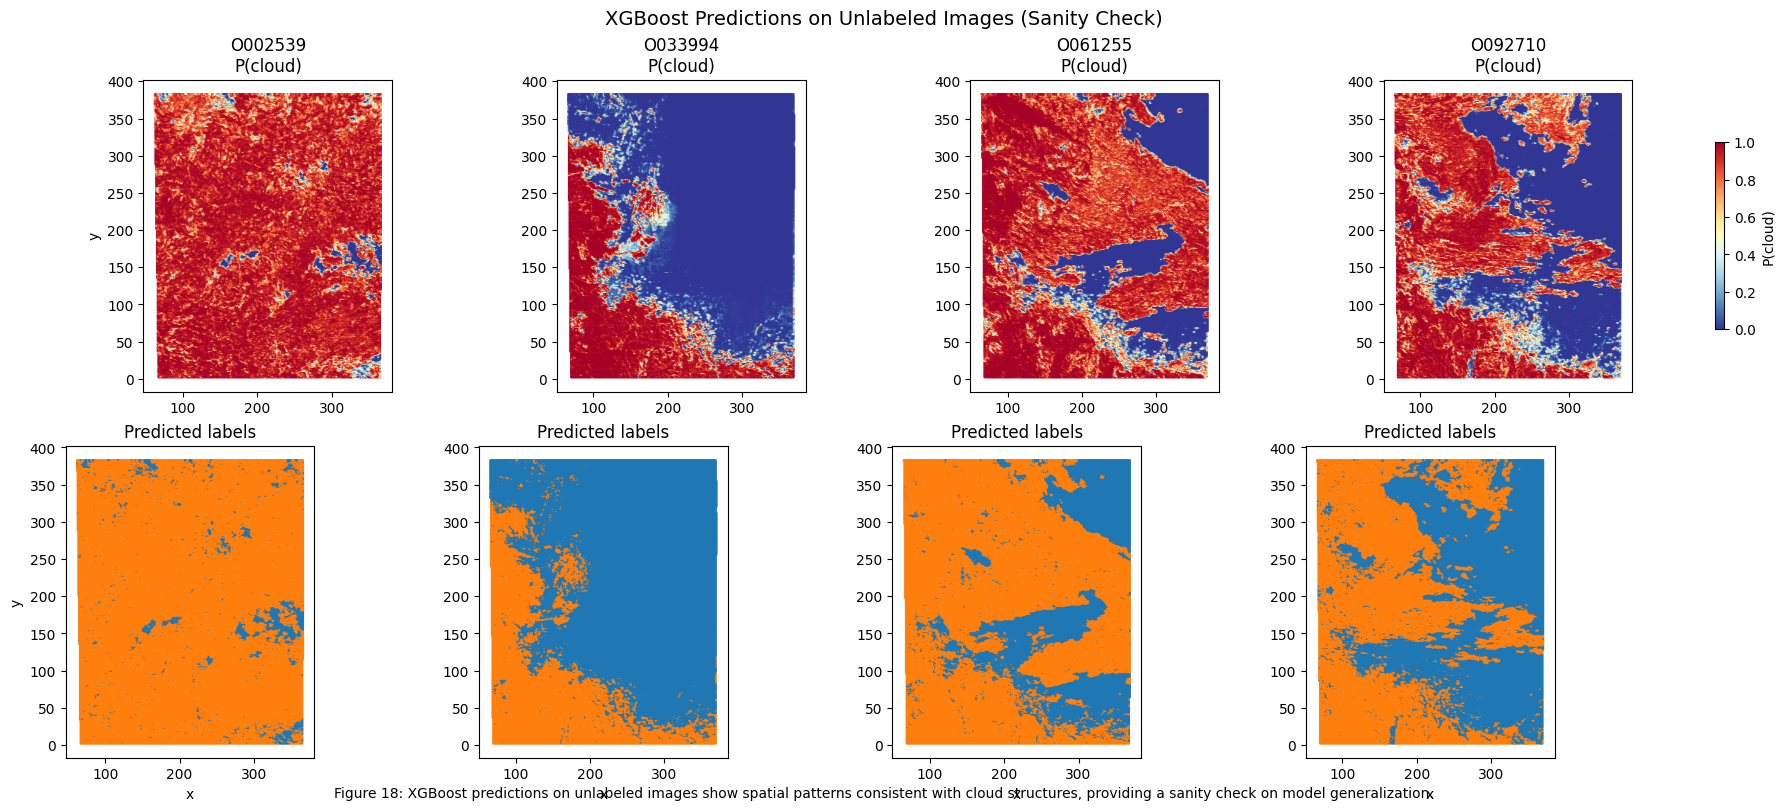

In [ ]:
# Sanity check: predict on unlabeled images
import glob
import importlib
import model
from sklearn.preprocessing import StandardScaler as SS
from features import engineer_features_unlabeled
from model import make_xgb

importlib.reload(model)

# Pick 4 unlabeled images for visualization
labeled_names = {"O012791.npz", "O013257.npz", "O013490.npz"}
all_fps = sorted(glob.glob("../data/image_data/*.npz"))
unlabeled_fps = [fp for fp in all_fps if fp.split("/")[-1] not in labeled_names]

# Select a few spread across the dataset
step = max(1, len(unlabeled_fps) // 4)
sample_fps = unlabeled_fps[::step][:4]

# Fit reusable full-feature model/scaler on labeled train split
x_train_full_ref = np.column_stack([Xb_train, Xn_train, train_ae[ae_feature_cols].to_numpy(float)])
sc_full = SS().fit(x_train_full_ref)
x_train_full_sc_ref = sc_full.transform(x_train_full_ref)
xgb_full = make_xgb(spw)
xgb_full.fit(x_train_full_sc_ref, yb_train)

# Fallback AE representation: train-set mean embedding for each pixel
ae_mean_vec = train_ae[ae_feature_cols].to_numpy(float).mean(axis=0)

fig, axes = plt.subplots(
    2, len(sample_fps), figsize=(4.5 * len(sample_fps), 8), constrained_layout=True
)

for col, fp in enumerate(sample_fps):
    npz = np.load(fp)
    key = list(npz.files)[0]
    data = npz[key]
    if data.shape[1] == 11:
        data = data[:, :10]  # remove label column if present

    name = fp.split("/")[-1].replace(".npz", "")
    y_c, x_c = data[:, 0], data[:, 1]

    # Base + engineered features from unlabeled image
    x_base_ul, x_new_ul, _, _ = engineer_features_unlabeled(data)
    ae_ul = np.tile(ae_mean_vec, (x_base_ul.shape[0], 1))

    x_ul_full = np.column_stack([x_base_ul, x_new_ul, ae_ul])
    x_ul_sc = sc_full.transform(x_ul_full)
    pred_ul = xgb_full.predict(x_ul_sc)
    prob_ul = xgb_full.predict_proba(x_ul_sc)[:, 1]

    # Plot: top row = predicted probability, bottom row = binary prediction
    ax_top = axes[0, col] if len(sample_fps) > 1 else axes[0]
    sc_top = ax_top.scatter(x_c, y_c, c=prob_ul, cmap="RdYlBu_r", s=0.2, vmin=0, vmax=1)
    ax_top.set_title(f"{name}\nP(cloud)")
    ax_top.set_aspect("equal")
    if col == 0:
        ax_top.set_ylabel("y")

    ax_bot = axes[1, col] if len(sample_fps) > 1 else axes[1]
    colors_pred = np.where(pred_ul == 1, "C1", "C0")
    ax_bot.scatter(x_c, y_c, c=colors_pred, s=0.2)
    ax_bot.set_title("Predicted labels")
    ax_bot.set_aspect("equal")
    ax_bot.set_xlabel("x")
    if col == 0:
        ax_bot.set_ylabel("y")

    cloud_frac = pred_ul.mean()
    print(f"  {name}: {len(pred_ul)} pixels, predicted cloud fraction = {cloud_frac:.2%}")

fig.colorbar(
    sc_top,
    ax=axes[0, :].tolist() if len(sample_fps) > 1 else [axes[0]],
    shrink=0.6,
    label="P(cloud)",
)
fig.suptitle("XGBoost Predictions on Unlabeled Images (Sanity Check)", fontsize=14)
plt.savefig("../figures/unlabeled_predictions.png", dpi=150, bbox_inches="tight")
plt.gcf().subplots_adjust(bottom=0.16)
plt.gcf().text(0.5, 0.01, "Figure 18: XGBoost predictions on unlabeled images show spatial patterns consistent with cloud structures, providing a sanity check on model generalization.", ha="center", fontsize=10, wrap=True)
plt.show()

**Stability and generalization interpretation**
The robustness and generalization of our model are further validated through a series of rigorous evaluations. In terms of feature perturbation robustness, when Gaussian noise ($\sigma$) is added to test features, the prediction flip rate (fraction of pixels where predicted label changes) rises smoothly from 0.20% at σ=0.01 to 5.27% at σ=0.50, while mean probability shift rises from 0.0019 to 0.0588. This demonstrates good local robustness: under mild perturbations ($\sigma \leq 0.1$), fewer than 1% of predictions flip, but larger noise ($\sigma = 0.5$) causes substantial decision-boundary crossings, just as expected.
Regarding train/test rotation stability, cross-validating across all three possible train/test image combinations reveals asymmetric generalization: performance is strong when testing on images 2 and 3 (AUROC 0.9982 and 0.9870), but substantially weaker on image 1 (AUROC 0.8363). This ~0.16 gap suggests dataset shift: image 1 may have different radiometric or cloud coverage characteristics than the training images, highlighting the importance of diverse scene sampling.
Finally, as an unlabeled-image sanity check, qualitative predictions on four held-out unlabeled images (O002539, O033994, O061255, O092710) produce spatially contiguous cloud-like regions (cloud fractions 95.46%, 29.61%, 74.59%, 54.63%) rather than random pixel-level noise. The spatial coherence supports model plausibility, though ground truth validation would be necessary for quantitative assessment.

## Results and interpretation

All three classifiers achieve strong test performance and adding autoencoder embeddings to the full feature set yields the best test AUROC , confirming that unsupervised latent representations capture spatial textures not fully expressed by hand-crafted statistics. However, the incremental gains from embeddings are modest , indicating that experts' features remain the primary discriminative signal and embeddings refine predictions at decision boundaries rather than providing orthogonal information.

Based on superior test generalization, XGBoost trained on the full 53-dimensional feature space is selected for detailed post-hoc diagnostics. Feature importance analysis reveals that spatial statistics and engineered interactions dominate over raw radiances, highlighting the value of explicit feature engineering. In contrast, Logistic Regression places greater weight on direct feature coefficients, showing how linear models prioritize different feature combinations than non-linear ensembles. Misclassification analysis shows an overall error rate of 2.64%, with 95% being false positives reflecting the model's tendency to predict clouds in ambiguous boundary regions where expert labels themselves may be uncertain. Robustness testing under feature perturbation demonstrates good local stability (< 1% prediction flip rate for noise $\sigma \leq 0.1$), while cross-image rotation validation reveals asymmetric dataset shift: test AUROC is strong on images 2 and 3 but notably weaker on image 1, suggesting radiometric or cloud-coverage differences that need diverse scene sampling in operational deployment.

# Bibliography

[1] Shi, T., Yu, B., Clothiaux, E. E., & Braverman, A. (2008). Daytime Arctic Cloud Detection Based on Multi-Angle Satellite Data With Case Studies. Journal of the American Statistical Association, 103, 584–593.

# Appendix: Academic honesty

## Statement

We confirm that this report is based on our own work. We completed the analysis, coding, and interpretation as a group. Any assistance or outside resources that contributed to the project have been properly cited. We view academic honesty as a basic requirement of research because it ensures credibility and fairness in academic work. We understand the importance of maintaining academic integrity in all our submissions.

## LLM Usage

During this project, we used LLMs like ChatGPT and Gemini in a very limited and supplementary way. They were only used for small tasks such as fixing minor coding errors, helping with visualizations, and checking grammar. We carefully reviewed and revised anything generated by these tools before using it. All final decisions about the code, analysis, and wording were made by us, and we take full responsibility for the final version of the report. 